In this notebook Seamese network model for handwriting author verification trained. As backbone CNN+crossViT with contrastive loss +BCE used. 

Let's import training dataset

In [1]:
#importing dataset
!pip install -q gdown

file_id = "1xpXGz2iJ7VhRG7iSZptX7V5v4dALLhvl"
output_name = "all_data_3.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1xpXGz2iJ7VhRG7iSZptX7V5v4dALLhvl
From (redirected): https://drive.google.com/uc?id=1xpXGz2iJ7VhRG7iSZptX7V5v4dALLhvl&confirm=t&uuid=559df890-f388-4362-8558-503a80982650
To: /content/all_data_3.zip
100% 1.76G/1.76G [00:26<00:00, 66.4MB/s]


In [2]:
import zipfile
import os

with zipfile.ZipFile("all_data_3.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

# Посмотрите, что получилось
os.listdir("/kaggle/working/")

['all_data_3']

In [3]:
DATA_ROOT = "/kaggle/working/all_data_3"

Now importing val and test datasets in .pkl files.

In [15]:
val_dataset_file="1AUeTVTv7dkVVabhnNLEDEFg6FEDTLyx7"
output_name = "val_pairs.pkl"

!gdown --id {val_dataset_file} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1AUeTVTv7dkVVabhnNLEDEFg6FEDTLyx7
To: /content/val_pairs.pkl
100% 145k/145k [00:00<00:00, 113MB/s]


In [4]:
test_dataset_file="17eaXxFbrPBEg0qoVBHP3ryICsLJo9hIF"
output_name = "test_pairs.pkl"

!gdown --id {test_dataset_file} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=17eaXxFbrPBEg0qoVBHP3ryICsLJo9hIF
To: /content/test_pairs.pkl
100% 95.7k/95.7k [00:00<00:00, 110MB/s]


In [16]:
DATA_ROOT_val_pairs = "/kaggle/working/val_pairs.pkl"
DATA_ROOT_test_pairs = "/kaggle/working/test_pairs.pkl"

In [6]:
!pip install torchvision

In [ ]:
import os
from pathlib import Path
import cv2
import numpy as np
import shutil
import random
import torch

from torch.utils.data import Dataset
import PIL
from PIL import Image
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader

import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, LinearLR, CosineAnnealingLR, SequentialLR
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from torchvision.models import resnet18, ResNet18_Weights

import matplotlib.pyplot as plt

from torchvision.utils import make_grid

from sklearn.manifold import TSNE



In [8]:
def set_seed(seed=42):
    """Fix all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"All seeds fixed to {seed}")
set_seed(42)

All seeds fixed to 42


Let's create class SiameseNetworkDataset for our data.
The dataset takes random pairs and create either positive (one author) or negative pair. The labels are created at random, the balance shall be ~50/50.
The pairs are created 'on the fly'.

In [9]:
class Pairs_Dataset(Dataset):
    def __init__(self, root, transform=None, size=100,
                 authors_list=None, iam_ratio=0.5):
        """
        Dataset for Siamese Network with Contrastive Loss.
        Supports IAM (handwriting lines), CEDAR, Bengali, Hindi (signatures with forgeries).

        Args:
            root: Root directory containing 'iam', 'cedar', 'bengali', 'hindi' folders
            transform: Image transformations
            size: Number of pairs per epoch
            authors_list: List of author IDs to include (for train/val split)
            iam_ratio: Probability of sampling from IAM (0.5 = 50% IAM)
        """
        self.transform = transform
        self.size = size
        self.iam_ratio = iam_ratio

        # Data structures
        self.iam_data = {}
        self.cedar_original = {}
        self.cedar_forgery = {}
        self.bengali_original = {}
        self.bengali_forgery = {}
        self.hindi_original = {}
        self.hindi_forgery = {}

        # Scan IAM folder
        iam_path = os.path.join(root, 'iam')
        if os.path.exists(iam_path):
            for folder in os.listdir(iam_path):
                author_path = os.path.join(iam_path, folder)
                if not os.path.isdir(author_path):
                    continue

                author_id = folder
                valid_images = []
                for file in os.listdir(author_path):
                    if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        continue

                    img_path = os.path.join(author_path, file)
                    try:
                        with Image.open(img_path) as img:
                            img.verify()
                        valid_images.append(img_path)
                    except Exception:
                        continue

                if valid_images:
                    self.iam_data[author_id] = valid_images

        # Scan CEDAR folder
        cedar_path = os.path.join(root, 'cedar')
        if os.path.exists(cedar_path):
            cedar_original_path = os.path.join(cedar_path, 'original')
            if os.path.exists(cedar_original_path):
                for author_id in os.listdir(cedar_original_path):
                    author_path = os.path.join(cedar_original_path, author_id)
                    if not os.path.isdir(author_path):
                        continue

                    valid_images = []
                    for file in os.listdir(author_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(author_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue

                    if valid_images:
                        self.cedar_original[author_id] = valid_images

            cedar_forgery_path = os.path.join(cedar_path, 'forgery')
            if os.path.exists(cedar_forgery_path):
                for author_id in os.listdir(cedar_forgery_path):
                    author_path = os.path.join(cedar_forgery_path, author_id)
                    if not os.path.isdir(author_path):
                        continue

                    valid_images = []
                    for file in os.listdir(author_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(author_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue

                    if valid_images:
                        self.cedar_forgery[author_id] = valid_images

        # Scan Bengali folder
        bengali_path = os.path.join(root, 'bengali')
        if os.path.exists(bengali_path):
            for author_id in os.listdir(bengali_path):
                author_path = os.path.join(bengali_path, author_id)
                if not os.path.isdir(author_path):
                    continue

                genuine_path = os.path.join(author_path, 'genuine')
                if os.path.exists(genuine_path):
                    valid_images = []
                    for file in os.listdir(genuine_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(genuine_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.bengali_original[author_id] = valid_images

                forge_path = os.path.join(author_path, 'forge')
                if os.path.exists(forge_path):
                    valid_images = []
                    for file in os.listdir(forge_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(forge_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.bengali_forgery[author_id] = valid_images

        # Scan Hindi folder
        hindi_path = os.path.join(root, 'hindi')
        if os.path.exists(hindi_path):
            for author_id in os.listdir(hindi_path):
                author_path = os.path.join(hindi_path, author_id)
                if not os.path.isdir(author_path):
                    continue

                genuine_path = os.path.join(author_path, 'genuine')
                if os.path.exists(genuine_path):
                    valid_images = []
                    for file in os.listdir(genuine_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(genuine_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.hindi_original[author_id] = valid_images

                forge_path = os.path.join(author_path, 'forge')
                if os.path.exists(forge_path):
                    valid_images = []
                    for file in os.listdir(forge_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(forge_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.hindi_forgery[author_id] = valid_images

        # Filter by authors_list if provided
        if authors_list is not None:
            author_set = set(authors_list)
            self.iam_data = {k: v for k, v in self.iam_data.items() if k in author_set}
            self.cedar_original = {k: v for k, v in self.cedar_original.items() if k in author_set}
            self.cedar_forgery = {k: v for k, v in self.cedar_forgery.items() if k in author_set}
            self.bengali_original = {k: v for k, v in self.bengali_original.items() if k in author_set}
            self.bengali_forgery = {k: v for k, v in self.bengali_forgery.items() if k in author_set}
            self.hindi_original = {k: v for k, v in self.hindi_original.items() if k in author_set}
            self.hindi_forgery = {k: v for k, v in self.hindi_forgery.items() if k in author_set}

        # Build author lists
        self.iam_authors = [a for a, imgs in self.iam_data.items() if len(imgs) >= 2]
        self.iam_all_authors = list(self.iam_data.keys())

        def build_signature_lists(original_dict, forgery_dict):
            authors_with_original = [a for a, imgs in original_dict.items() if len(imgs) >= 2]
            authors_with_forgery = [a for a in original_dict.keys()
                                     if a in forgery_dict
                                     and len(original_dict[a]) >= 1
                                     and len(forgery_dict[a]) >= 1]
            all_authors = list(original_dict.keys())
            return authors_with_original, authors_with_forgery, all_authors

        self.cedar_authors, self.cedar_authors_with_forgery, self.cedar_all_authors = build_signature_lists(self.cedar_original, self.cedar_forgery)
        self.bengali_authors, self.bengali_authors_with_forgery, self.bengali_all_authors = build_signature_lists(self.bengali_original, self.bengali_forgery)
        self.hindi_authors, self.hindi_authors_with_forgery, self.hindi_all_authors = build_signature_lists(self.hindi_original, self.hindi_forgery)

        # Combine signature datasets
        self.signature_datasets = []
        if self.cedar_authors or self.cedar_authors_with_forgery:
            self.signature_datasets.append(('cedar', self.cedar_original, self.cedar_forgery,
                                           self.cedar_authors, self.cedar_authors_with_forgery, self.cedar_all_authors))
        if self.bengali_authors or self.bengali_authors_with_forgery:
            self.signature_datasets.append(('bengali', self.bengali_original, self.bengali_forgery,
                                           self.bengali_authors, self.bengali_authors_with_forgery, self.bengali_all_authors))
        if self.hindi_authors or self.hindi_authors_with_forgery:
            self.signature_datasets.append(('hindi', self.hindi_original, self.hindi_forgery,
                                           self.hindi_authors, self.hindi_authors_with_forgery, self.hindi_all_authors))


    def __len__(self):
        return self.size

    def _get_iam_pair(self, label):
        """IAM: positive=same author, negative=different authors"""
        if label == 1:
            if not self.iam_authors:
                return None, None, None
            author = random.choice(self.iam_authors)
            images = self.iam_data[author]
            if len(images) < 2:
                return None, None, None
            img1_path, img2_path = random.sample(images, 2)
        else:
            if len(self.iam_all_authors) < 2:
                return None, None, None
            author1, author2 = random.sample(self.iam_all_authors, 2)
            img1_path = random.choice(self.iam_data[author1])
            img2_path = random.choice(self.iam_data[author2])
        return img1_path, img2_path, label

    def _get_signature_pair(self, dataset_name, original_dict, forgery_dict,
                           authors, authors_with_forgery, all_authors, label):
        """
        Signature datasets (CEDAR, Bengali, Hindi):
        - Positive: 2 genuine signatures from the SAME author
        - Negative: 1 genuine + 1 forgery from the SAME author (ALWAYS hard negative)
        """
        if label == 1:
            # Positive: two genuine signatures from the same author
            if not authors:
                return None, None, None
            author = random.choice(authors)
            original_images = original_dict[author]
            if len(original_images) < 2:
                return None, None, None
            img1_path, img2_path = random.sample(original_images, 2)
        else:
            # Negative: original + forgery from the SAME author (ALWAYS hard negative)
            if not authors_with_forgery:
                return None, None, None
            author = random.choice(authors_with_forgery)
            original_images = original_dict[author]
            forgery_images = forgery_dict[author]
            if not original_images or not forgery_images:
                return None, None, None
            img1_path = random.choice(original_images)
            img2_path = random.choice(forgery_images)

        return img1_path, img2_path, label

    def __getitem__(self, idx):
        use_iam = random.random() < self.iam_ratio
        label = random.randint(0, 1)

        img1_path, img2_path, final_label = None, None, None

        if use_iam and self.iam_authors:
            img1_path, img2_path, final_label = self._get_iam_pair(label)

        if img1_path is None and self.signature_datasets:
            dataset_name, original_dict, forgery_dict, authors, authors_with_forgery, all_authors = random.choice(self.signature_datasets)
            result = self._get_signature_pair(dataset_name, original_dict, forgery_dict,
                                              authors, authors_with_forgery, all_authors, label)
            img1_path, img2_path, final_label = result

        if img1_path is None:
            # Fallback: try any available dataset
            if self.iam_authors:
                img1_path, img2_path, final_label = self._get_iam_pair(1)
            elif self.signature_datasets:
                dataset_name, original_dict, forgery_dict, authors, authors_with_forgery, all_authors = random.choice(self.signature_datasets)
                result = self._get_signature_pair(dataset_name, original_dict, forgery_dict,
                                                  authors, authors_with_forgery, all_authors, 1)
                img1_path, img2_path, final_label = result

        img1 = Image.open(img1_path).convert('L')
        img2 = Image.open(img2_path).convert('L')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, final_label

In [11]:
train_authors=['353', '662', '546', '181', '126', '104', '15', '72', '629', '094', '10', '139', '090', '636', '160', '092', '136', '328', '190', '20', '392', '652',
               '5', '405', '378', '236', '650', '573', '162', '349', '515', '59', '128', '421', '48', '14', '3', '262', '454', '670', '281', '543', '435', '632', '393',
               '192', '594', '237', '270', '250', '153', '320', '6', '531', '418', '399', '460', '603', '027', '598', '276', '083', '216', '391', '131', '2', '496', '53',
               '618', '093', '318', '214', '189', '110', '425', '389', '420', '401', '32', '562', '170', '93', '609', '616', '357', '597', '80', '626', '332', '119', '060',
               '487', '025', '547', '390', '513', '147', '072', '553', '183', '623', '615', '500', '198', '011', '174', '647', '664', '278', '445', '290', '210', '272',
               '448', '503', '534', '69', '88', '68', '120', '24', '464', '398', '568', '070', '610', '628', '591', '31', '529', '215', '149', '138', '118', '451', '572',
               '17', '339', '049', '25', '60', '26', '243', '054', '032', '586', '471', '377', '342', '87', '58', '620', '179', '89', '109', '304', '034', '365', '373',
               '363', '169', '071', '49', '579', '382', '444', '412', '485', '310', '473', '619', '084', '518', '535', '144', '542', '280', '145', '520', '156', '099',
               '576', '570', '589', '059', '595', '208', '361', '307', '558', '101', '67', '030', '38', '115', '19', '371', '340', '567', '319', '352', '274', '530',
               '102', '259', '555', '525', '462', '226', '27', '539', '041', '607', '508', '344', '182', '79', '288', '085', '095', '239', '267', '584', '92', '639',
               '410', '70', '184', '121', '492', '114', '509', '053', '334', '246', '490', '449', '255', '440', '185', '580', '294', '477', '495', '436', '291', '641',
               '33', '35', '21', '089', '103', '289', '370', '221', '466', '242', '076', '423', '379', '020', '008', '224', '019', '248', '98', '067', '483', '37', '663',
               '064', '582', '086', '031', '23', '563', '611', '305', '96', '472', '283', '043', '414', '141', '34', '151', '065', '621', '55', '91', '260', '231', '048',
               '478', '499', '606', '056', '354', '229', '045', '81', '096', '343', '408', '264', '155', '596', '253', '461', '235', '042', '73', '347', '482', '475',
               '386', '197', '394', '431', '65', '634', '416', '90', '36', '303', '122', '018', '517', '668', '252', '097', '228', '107', '413', '082', '556', '203',
               '494', '285', '028', '191', '592', '256', '578', '171', '002', '188', '526', '367', '116', '522', '234', '71', '30', '035', '364', '268', '327', '484',
               '146', '312', '533', '4', '046', '209', '433', '86', '402', '350', '640', '428', '453', '279', '536', '441', '037', '614', '47', '296', '159', '315', '062',
               '000', '407', '549', '080', '335', '079', '504', '659', '419', '117', '540', '081', '452', '351', '521', '384', '051', '648', '524', '036', '411', '75',
               '645', '325', '559', '211', '583', '527', '1', '502', '447', '7', '193', '565', '99', '152', '551', '608', '403', '195', '298', '006', '004', '077',
               '187', '301', '491', '366', '130', '538', '206', '324', '175', '098', '247', '180', '222', '251', '28', '63', '474', '671', '545', '088', '052', '388',
               '257', '123', '172', '486', '83', '554', '41', '417', '430', '660', '023', '56', '380', '40', '227', '566', '026', '219', '481', '575', '309', '489', '638',
               '148', '45', '258', '249', '200', '356', '331', '263', '232', '630', '063', '164', '544', '168', '359', '443', '047', '186', '85', '470', '336', '176',
               '078', '651', '196', '577', '455', '012', '666', '571', '317', '376', '429', '655', '314', '52', '600', '058', '212', '016', '022', '217', '94', '106',
               '44', '244', '77', '199', '8', '329', '22', '519', '561', '643', '64', '137', '501', '493']
val_authors=['456', '9', '426', '97', '322', '133', '13', '021', '157', '355', '166', '375', '627', '345', '605', '140', '135', '161', '163', '593', '476', '84', '225',
             '223', '62', '213', '512', '266', '537', '446', '100', '346', '422', '233', '613', '167', '261', '360', '127', '633', '292', '442', '341', '564', '468',
             '654', '467', '302', '330', '220', '465', '458', '18', '299', '326', '286', '014', '528', '635', '007', '569', '548', '333', '57', '207', '581', '039',
             '50', '338', '439', '205', '54', '552', '173', '348', '644', '488', '665', '362', '498', '409', '637', '587', '075', '300', '108', '642', '74', '400',
             '76', '074', '125', '51', '091', '017', '295', '245', '624', '142', '383', '585', '457', '230', '040', '497', '073', '432', '369', '275', '506', '201',
             '241', '129', '218']
test_authors=['43', '134', '516', '055', '204', '313', '523', '068', '404', '372', '601', '395', '469', '617', '009', '254', '588', '194', '337', '178', '511', '29',
              '015', '82', '287', '124', '599', '112', '39', '541', '293', '010', '143', '625', '132', '95', '158', '649', '622', '316', '282', '667', '532', '321',
              '177', '013', '505', '297', '631', '42', '658', '66', '368', '202', '510', '590', '165', '459', '154', '434', '61', '005', '397', '105', '602', '265',
              '46', '396', '387', '450', '323', '001', '087', '240', '113', '066', '604', '044', '061', '550', '463', '653', '033', '273', '669', '514', '150', '024',
              '424', '479', '069', '16', '574', '308', '238', '038', '415', '560', '385', '557', '277', '480', '612', '661', '111', '12', '427', '78', '050', '003',
              '269', '11', '406', '029']


In [12]:
train_transform = T.Compose([
    T.Resize((240, 240)),  #use 240*240 for the model
    T.RandomRotation(3),
    T.RandomAffine(0, translate=(0.02, 0.02), scale=(0.98, 1.02)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

val_transform = T.Compose([
    T.Resize((240, 240)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

test_transform = T.Compose([
    T.Resize((240, 240)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

In [13]:
train_dataset = Pairs_Dataset(
    root=DATA_ROOT,
    transform=train_transform,
    train=True,
    size=5000,
    authors_list=train_authors
)

In [17]:
class SavedPairsDataset(Dataset):
    def __init__(self, pairs_file, transform=None):
        with open(pairs_file, 'rb') as f:
            self.pairs = pickle.load(f)
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1_path, img2_path, label = self.pairs[idx]

        img1 = Image.open(img1_path).convert('L')
        img2 = Image.open(img2_path).convert('L')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, label

# # Создание и сохранение
# val_pairs = []
# test_pairs = []
# temp_dataset_val = Pairs_Dataset(root=DATA_ROOT, transform=None, train=False,
#                               size=2000, authors_list=val_authors)
# temp_dataset_test = Pairs_Dataset(root=DATA_ROOT, transform=None, train=False,
#                               size=1000, authors_list=test_authors)
# for i in range(len(temp_dataset_val)):
#     img1, img2, label, p1, p2 = temp_dataset_val[i]
#     val_pairs.append((p1, p2, label))

# for i in range(len(temp_dataset_test)):
#     img1, img2, label, p1, p2 = temp_dataset_test[i]
#     test_pairs.append((p1, p2, label))

# with open('val_pairs.pkl', 'wb') as f:
#     pickle.dump(val_pairs, f)

# with open('test_pairs.pkl', 'wb') as f:
#     pickle.dump(test_pairs, f)

# Загрузка
val_dataset = SavedPairsDataset('val_pairs.pkl', transform=val_transform)
test_dataset = SavedPairsDataset('test_pairs.pkl', transform=test_transform)

Label: 1
Size img1: torch.Size([1, 240, 240])
Size img2: torch.Size([1, 240, 240])


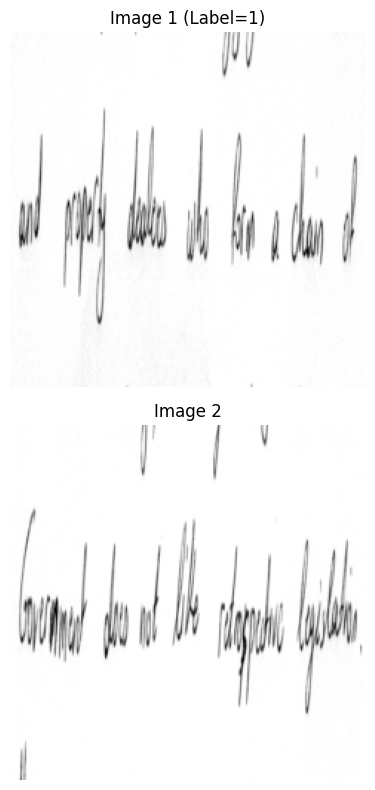

In [18]:
img1, img2, label = test_dataset[0]

print(f"Label: {label}")
print(f"Size img1: {img1.shape}")
print(f"Size img2: {img2.shape}")

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.imshow(img1[0], cmap='gray')
plt.title(f"Image 1 (Label={label})")
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(img2[0], cmap='gray')
plt.title("Image 2")
plt.axis('off')

plt.tight_layout()
plt.show()

In [19]:
labels=[]

for i in range(len(train_dataset)):
  labels.append(train_dataset[i][2])

KeyboardInterrupt: 

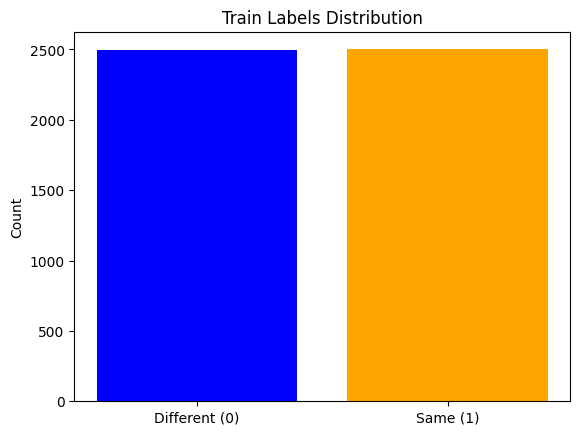

In [ ]:
counts = [labels.count(0), labels.count(1)]

plt.bar(['Different (0)', 'Same (1)'], counts, color=['blue', 'orange'])
plt.ylabel('Count')
plt.title('Train Labels Distribution')
plt.show()

In [20]:
# creating DataLoader
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

This code implements a hybrid CNN-ViT model with a classification head for handwriting verification.

Architecture Overview:

CNN Branch (ResNet-18): Extracts local features from grayscale images through three ResNet layers with FPN (Feature Pyramid Network) that outputs 128-channel features from each level (total 384 dimensions).

CrossViT Branch: Processes the same image through a CrossViT Base 240 transformer adapted for grayscale input, outputting 768-dimensional features.

Fusion Module: Concatenates CNN (384) and CrossViT (768) features → Linear(1152→512) → BatchNorm → ReLU → Dropout(0.3) → Linear(512→256) → BatchNorm → L2 normalization.

Classification Head: Takes the L2-normalized embeddings from two images, computes element-wise absolute difference, and passes through Linear(256→128) → ReLU → Dropout(0.2) → Linear(128→1) to produce a binary logit (same author or different).

Key Differences from Previous Version:

Returns logits (classification output), emb1, and emb2 instead of just embeddings

Uses absolute difference between embeddings fed into a classifier rather than contrastive loss

Designed for binary cross-entropy loss training

Forward Pass:

Takes two images (x1, x2)

Returns: (logits, embedding1, embedding2) where logits are used for classification

In [21]:
def adapt_conv2d_to_grayscale(module):
    if isinstance(module, nn.Conv2d) and module.in_channels == 3:
        new_conv = nn.Conv2d(
            1, module.out_channels,
            kernel_size=module.kernel_size,
            stride=module.stride,
            padding=module.padding,
            dilation=module.dilation,
            groups=module.groups,
            bias=module.bias is not None
        )
        with torch.no_grad():
            new_conv.weight.data = module.weight.data.mean(dim=1, keepdim=True)
            if module.bias is not None:
                new_conv.bias.data = module.bias.data
        module.in_channels = 1
        module.weight.data = new_conv.weight.data
        if module.bias is not None:
            module.bias.data = new_conv.bias.data
        return True
    return False


def adapt_model_to_grayscale(model):
    adapted_count = 0
    for module in model.modules():
        if adapt_conv2d_to_grayscale(module):
            adapted_count += 1
    return model


class CNNCrossViTWithHead(nn.Module):
    def __init__(self, embedding_size=256, pretrained=True, freeze_backbone='partial'):
        super(CNNCrossViTWithHead, self).__init__()

        #1. CNN BRANCH (ResNet-18)
        if pretrained:
            resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        else:
            resnet = resnet18(weights=None)

        original_conv1 = resnet.conv1
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            resnet.conv1.weight.data = original_conv1.weight.data.mean(dim=1, keepdim=True)

        self.cnn_conv1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.cnn_layer1 = resnet.layer1
        self.cnn_layer2 = resnet.layer2
        self.cnn_layer3 = resnet.layer3

        # FPN
        self.fpn_lateral = nn.ModuleList([
            nn.Conv2d(64, 128, 1),
            nn.Conv2d(128, 128, 1),
            nn.Conv2d(256, 128, 1)
        ])
        self.fpn_output = nn.ModuleList([
            nn.Conv2d(128, 128, 3, padding=1),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.Conv2d(128, 128, 3, padding=1)
        ])

        #2. CROSSVIT BRANCH
        self.crossvit = timm.create_model('crossvit_base_240', pretrained=pretrained, num_classes=0)
        adapt_model_to_grayscale(self.crossvit)

        cnn_out_dim = 128 * 3
        crossvit_out_dim = self.crossvit.num_features

        #3. FUSION
        self.fusion = nn.Sequential(
            nn.Linear(cnn_out_dim + crossvit_out_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, embedding_size),
            nn.BatchNorm1d(embedding_size)
        )

        #4. CLASSIFICATION HEAD
        self.classifier = nn.Sequential(
            nn.Linear(embedding_size, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

        self.embedding_size = embedding_size

        #5. FREEZE LAYERS
        self._freeze_layers(freeze_backbone)

        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"CNN-CrossViT with Classification Head initialized")
        print(f"Total parameters: {total_params:,}")
        print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

    def _freeze_layers(self, freeze_mode):
        if freeze_mode == 'partial':
            # CNN Branch
            for param in self.cnn_conv1.parameters():
                param.requires_grad = False
            for param in self.cnn_layer1.parameters():
                param.requires_grad = False
            for param in self.cnn_layer2.parameters():
                param.requires_grad = False

            # CrossViT Branch - freeze early transformer blocks
            self._freeze_crossvit_transformer_blocks(num_trainable_blocks=4)

        elif freeze_mode == 'full':
            # Freeze all CNN
            for param in self.cnn_conv1.parameters():
                param.requires_grad = False
            for param in self.cnn_layer1.parameters():
                param.requires_grad = False
            for param in self.cnn_layer2.parameters():
                param.requires_grad = False
            for param in self.cnn_layer3.parameters():
                param.requires_grad = False

            # Freeze all CrossViT
            for param in self.crossvit.parameters():
                param.requires_grad = False

    def _freeze_crossvit_transformer_blocks(self, num_trainable_blocks=4):
        """
        Freeze CrossViT transformer blocks.
        Structure: blocks (3 MultiScaleBlock) → each has .blocks (4 transformer Block)
        Total: 12 transformer blocks
        """
        all_transformer_blocks = []

        # Collect all transformer blocks from all stages
        if hasattr(self.crossvit, 'blocks'):
            for stage_idx, multi_scale_block in enumerate(self.crossvit.blocks):
                if hasattr(multi_scale_block, 'blocks'):
                    for block_idx, transformer_block in enumerate(multi_scale_block.blocks):
                        all_transformer_blocks.append({
                            'stage': stage_idx,
                            'block': block_idx,
                            'module': transformer_block
                        })

        total_blocks = len(all_transformer_blocks)
        print(f"Found {total_blocks} transformer blocks in CrossViT")

        if total_blocks == 0:
            for param in self.crossvit.parameters():
                param.requires_grad = False
            return

        # Freeze all except last N blocks
        frozen_count = 0
        trainable_count = 0

        for i, block_info in enumerate(all_transformer_blocks):
            if i < total_blocks - num_trainable_blocks:
                for param in block_info['module'].parameters():
                    param.requires_grad = False
                frozen_count += 1
            else:
                trainable_count += 1

    def _fpn_forward(self, c1, c2, c3):
        p3 = self.fpn_lateral[2](c3)
        p2 = self.fpn_lateral[1](c2)
        p1 = self.fpn_lateral[0](c1)

        p2 = p2 + F.interpolate(p3, size=p2.shape[-2:], mode='nearest')
        p1 = p1 + F.interpolate(p2, size=p1.shape[-2:], mode='nearest')

        p3 = self.fpn_output[2](p3)
        p2 = self.fpn_output[1](p2)
        p1 = self.fpn_output[0](p1)

        p1 = F.adaptive_avg_pool2d(p1, 1).flatten(1)
        p2 = F.adaptive_avg_pool2d(p2, 1).flatten(1)
        p3 = F.adaptive_avg_pool2d(p3, 1).flatten(1)

        return torch.cat([p1, p2, p3], dim=1)

    def forward_one(self, x):
        c1 = self.cnn_conv1(x)
        c2 = self.cnn_layer1(c1)
        c3 = self.cnn_layer2(c2)
        c4 = self.cnn_layer3(c3)
        cnn_features = self._fpn_forward(c2, c3, c4)

        crossvit_features = self.crossvit(x)

        combined = torch.cat([cnn_features, crossvit_features], dim=1)
        embedding = self.fusion(combined)

        return F.normalize(embedding, p=2, dim=1)

    def forward(self, x1, x2):
        emb1 = self.forward_one(x1)
        emb2 = self.forward_one(x2)

        # Compute distance for classification
        distance = torch.abs(emb1 - emb2)
        logits = self.classifier(distance).squeeze(1)

        return logits, emb1, emb2

In [22]:
class ContrastiveLoss(nn.Module):
    """Contrastive loss"""

    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        # Eucledian distance
        distance = F.pairwise_distance(output1, output2)

        loss = label * torch.pow(distance, 2) / 2
        loss += (1 - label) * torch.pow(torch.clamp(self.margin - distance, min=0.0), 2) / 2

        return loss.mean()

In [23]:
def train_cnn_crossvit_model(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=0.0001,
    device=None,
    save_path='best_cnn_crossvit.pth',
    weight_decay=0.01,
    warmup_epochs=5,
    bce_weight=0.2
):
    """
    Training function for CNN-CrossViT model with Classification Head.
    Uses Contrastive Loss + BCE Loss (bce_weight=0.2)
    """


    model = model.to(device)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    warmup_scheduler = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_epochs)
    cosine_scheduler = CosineAnnealingLR(optimizer, T_max=epochs - warmup_epochs, eta_min=1e-6)
    scheduler = SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[warmup_epochs])

    contrastive_loss = ContrastiveLoss(margin=1.0)
    bce_loss_fn = nn.BCEWithLogitsLoss()

    # History
    history = {
        'train_loss': [], 'val_loss': [],
        'train_contrastive': [], 'val_contrastive': [],
        'train_bce': [], 'val_bce': [],
        'val_roc_auc': [], 'val_eer': [],
        'train_roc_auc': [], 'train_eer': [],
        'train_accuracy': [], 
        'val_accuracy': [],    
        'lr': []
    }
    best_val_roc_auc = 0.0

    for epoch in range(epochs):
        #TRAINING
        model.train()
        train_loss = 0.0
        train_contrastive = 0.0
        train_bce = 0.0
        train_labels = []
        train_probs = []
        train_distances = []

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for batch in pbar:

            img1, img2, labels = batch


            img1 = img1.to(device)
            img2 = img2.to(device)
            labels = labels.float().to(device)

            optimizer.zero_grad()

            logits, emb1, emb2 = model(img1, img2)

            distances = torch.norm(emb1 - emb2, p=2, dim=1)

            loss_c = contrastive_loss(emb1, emb2, labels)
            loss_bce_val = bce_loss_fn(logits, labels)
            loss = loss_c + bce_weight * loss_bce_val

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_contrastive += loss_c.item()
            train_bce += loss_bce_val.item()

            probs = torch.sigmoid(logits)
            train_labels.extend(labels.cpu().numpy())
            train_probs.extend(probs.detach().cpu().numpy())
            train_distances.extend(distances.detach().cpu().numpy())

            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'c': f'{loss_c.item():.3f}',
                'bce': f'{loss_bce_val.item():.3f}'
            })

        # Training metrics
        train_labels_np = np.array(train_labels)
        train_probs_np = np.array(train_probs)

        train_roc_auc = roc_auc_score(train_labels_np, train_probs_np) if len(set(train_labels_np)) > 1 else 0.5
        train_eer = calculate_eer(train_labels_np, train_probs_np)

        # Accuracy с threshold 0.5
        train_preds = (train_probs_np >= 0.5).astype(int)
        train_accuracy = (train_preds == train_labels_np).mean()

        #VALIDATION 
        model.eval()
        val_loss = 0.0
        val_contrastive = 0.0
        val_bce = 0.0
        val_labels = []
        val_probs = []
        val_distances = []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                img1, img2, labels = batch

                img1 = img1.to(device)
                img2 = img2.to(device)
                labels = labels.float().to(device)

                logits, emb1, emb2 = model(img1, img2)
                distances = torch.norm(emb1 - emb2, p=2, dim=1)

                loss_c = contrastive_loss(emb1, emb2, labels)
                loss_bce_val = bce_loss_fn(logits, labels)
                loss = loss_c + bce_weight * loss_bce_val

                val_loss += loss.item()
                val_contrastive += loss_c.item()
                val_bce += loss_bce_val.item()

                probs = torch.sigmoid(logits)
                val_labels.extend(labels.cpu().numpy())
                val_probs.extend(probs.cpu().numpy())
                val_distances.extend(distances.cpu().numpy())

        # Validation metrics
        val_labels_np = np.array(val_labels)
        val_probs_np = np.array(val_probs)

        val_roc_auc = roc_auc_score(val_labels_np, val_probs_np) if len(set(val_labels_np)) > 1 else 0.5
        val_eer = calculate_eer(val_labels_np, val_probs_np)

        # Accuracy с threshold 0.5
        val_preds = (val_probs_np >= 0.5).astype(int)
        val_accuracy = (val_preds == val_labels_np).mean()

        scheduler.step()

        # HISTORY
        history['train_loss'].append(train_loss / len(train_loader))
        history['val_loss'].append(val_loss / len(val_loader))
        history['train_contrastive'].append(train_contrastive / len(train_loader))
        history['val_contrastive'].append(val_contrastive / len(val_loader))
        history['train_bce'].append(train_bce / len(train_loader))
        history['val_bce'].append(val_bce / len(val_loader))
        history['train_roc_auc'].append(train_roc_auc)
        history['train_eer'].append(train_eer)
        history['train_accuracy'].append(train_accuracy) 
        history['val_roc_auc'].append(val_roc_auc)
        history['val_eer'].append(val_eer)
        history['val_accuracy'].append(val_accuracy)     
        history['lr'].append(optimizer.param_groups[0]['lr'])

        current_lr = optimizer.param_groups[0]['lr']
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {history['train_loss'][-1]:.4f} (C: {history['train_contrastive'][-1]:.4f}, BCE: {history['train_bce'][-1]:.4f})")
        print(f"  Train Acc:  {train_accuracy:.4f}, ROC-AUC: {train_roc_auc:.4f}, EER: {train_eer:.4f}")
        print(f"  Val Loss:   {history['val_loss'][-1]:.4f} (C: {history['val_contrastive'][-1]:.4f}, BCE: {history['val_bce'][-1]:.4f})")
        print(f"  Val Acc:    {val_accuracy:.4f}, ROC-AUC: {val_roc_auc:.4f}, EER: {val_eer:.4f}")
        print(f"  LR: {current_lr:.6f}")

        if val_roc_auc > best_val_roc_auc:
            best_val_roc_auc = val_roc_auc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_roc_auc': val_roc_auc,
                'val_eer': val_eer,
                'val_accuracy': val_accuracy,  
                'config': {
                    'embedding_size': model.embedding_size,
                    'bce_weight': bce_weight
                }
            }, save_path)
            print(f"Model saved! ROC-AUC: {val_roc_auc:.4f}, EER: {val_eer:.4f}, Acc: {val_accuracy:.4f}")

    return history

In [24]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
model =CNNCrossViTWithHead(
    embedding_size=256,
    pretrained=True,
    freeze_backbone='partial' 
)

history_cnn_crossvit_c_b_240 = train_cnn_crossvit_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=0.001,
    device=device,
    save_path='best_cnn_crossvit_c_b_240.pth',
    weight_decay=0.01,
    warmup_epochs=5
)
print(f"\nBest Val ROC-AUC: {max(history_cnn_crossvit_c_b_240['val_roc_auc'])*100:.2f}%")

Found 6 transformer blocks in CrossViT
CNN-CrossViT with Classification Head initialized
Total parameters: 107,597,249
Trainable parameters: 76,794,497 (71.4%)


Epoch 1/30 [Val]: 100%|██████████| 250/250 [01:23<00:00,  3.01it/s]



Epoch 1/30
  Train Loss: 0.3408 (C: 0.2022, BCE: 0.6928)
  Train Acc:  0.5090, ROC-AUC: 0.5341, EER: 0.4746
  Val Loss:   0.2766 (C: 0.1381, BCE: 0.6927)
  Val Acc:    0.4955, ROC-AUC: 0.6980, EER: 0.3560
  LR: 0.000208
Model saved! ROC-AUC: 0.6980, EER: 0.3560, Acc: 0.4955


Epoch 2/30 [Val]: 100%|██████████| 250/250 [01:22<00:00,  3.02it/s]



Epoch 2/30
  Train Loss: 0.2607 (C: 0.1270, BCE: 0.6685)
  Train Acc:  0.5776, ROC-AUC: 0.6564, EER: 0.3962
  Val Loss:   0.1951 (C: 0.0806, BCE: 0.5727)
  Val Acc:    0.7820, ROC-AUC: 0.8624, EER: 0.2255
  LR: 0.000406
Model saved! ROC-AUC: 0.8624, EER: 0.2255, Acc: 0.7820


...


Epoch 28/30
  Train Loss: 0.1109 (C: 0.0525, BCE: 0.2923)
  Train Acc:  0.8788, ROC-AUC: 0.9460, EER: 0.1200
  Val Loss:   0.0756 (C: 0.0354, BCE: 0.2013)
  Val Acc:    0.9210, ROC-AUC: 0.9835, EER: 0.0680
  LR: 0.000017
Model saved! ROC-AUC: 0.9835, EER: 0.0680, Acc: 0.9210


Epoch 29/30 [Val]: 100%|██████████| 250/250 [01:22<00:00,  3.03it/s]



Epoch 29/30
  Train Loss: 0.1095 (C: 0.0524, BCE: 0.2860)
  Train Acc:  0.8840, ROC-AUC: 0.9492, EER: 0.1190
  Val Loss:   0.0762 (C: 0.0351, BCE: 0.2055)
  Val Acc:    0.9205, ROC-AUC: 0.9826, EER: 0.0700
  LR: 0.000005


Epoch 30/30 [Val]: 100%|██████████| 250/250 [01:22<00:00,  3.02it/s]


Epoch 30/30
  Train Loss: 0.1114 (C: 0.0529, BCE: 0.2921)
  Train Acc:  0.8772, ROC-AUC: 0.9457, EER: 0.1216
  Val Loss:   0.0775 (C: 0.0359, BCE: 0.2082)
  Val Acc:    0.9165, ROC-AUC: 0.9830, EER: 0.0680
  LR: 0.000001

Best Val ROC-AUC: 98.35%


In [ ]:
history_cnn_crossvit_c_b_240

{'train_loss': [0.3408074179649353,
  0.2607143367290497,
  0.22953360866308212,
  0.21471500487923623,
  0.20141359446644783,
  0.1957249674141407,
  0.18343400642871857,
  0.16612997714281083,
  0.15922901294529437,
  0.15727774457931518,
  0.1483181692481041,
  0.15147958934903144,
  0.14581445064246654,
  0.14191335043311118,
  0.13969549845159054,
  0.13714138631522654,
  0.13041098037958146,
  0.1295858293145895,
  0.12625099305808543,
  0.12586965315937995,
  0.12075901265442371,
  0.1182803984671831,
  0.12075454331487417,
  0.11367380189001561,
  0.11468334872126579,
  0.11501240240931511,
  0.11861894059628249,
  0.11092581887543201,
  0.10954405658245087,
  0.1113582466237247],
 'val_loss': [0.27662774378061294,
  0.19511545911431313,
  0.15712939627468586,
  0.15575791224837304,
  0.1353959927484393,
  0.13264799120277165,
  0.10897787061333657,
  0.10987390282005072,
  0.09789539269357919,
  0.09617948158830404,
  0.09621799431741238,
  0.1016043155528605,
  0.091096838831

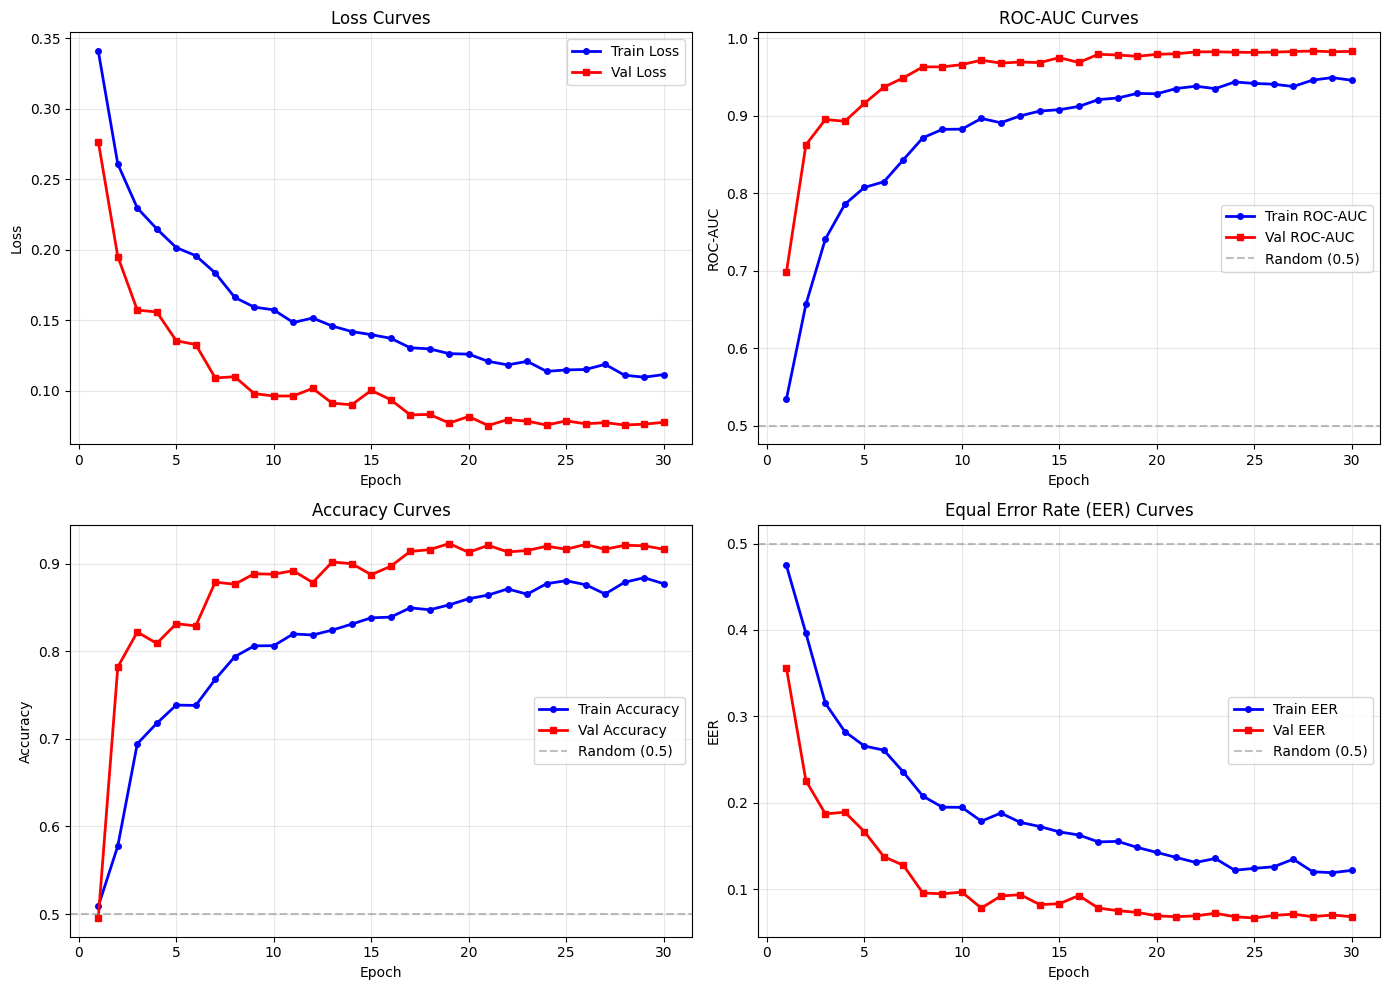

  Best Val ROC-AUC: 0.9835 (Epoch 28)
  Best Val Accuracy: 0.9230 (Epoch 19)
  Best Val EER: 0.0665 (Epoch 25)
  Val ROC-AUC: 0.9830
  Val Accuracy: 0.9165
  Val EER: 0.0680
  Train Loss: 0.1114
  Val Loss: 0.0775
  Best Val ROC-AUC: 0.9835
  Best Val Accuracy: 0.9230
  Best Val EER: 0.0665


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data from history_cnn_crossvit_c_b_240
epochs = range(1, len(history_cnn_crossvit_c_b_240['train_loss']) + 1)

train_loss = history_cnn_crossvit_c_b_240['train_loss']
val_loss = history_cnn_crossvit_c_b_240['val_loss']
train_roc_auc = history_cnn_crossvit_c_b_240['train_roc_auc']
val_roc_auc = history_cnn_crossvit_c_b_240['val_roc_auc']
train_accuracy = history_cnn_crossvit_c_b_240['train_accuracy']
val_accuracy = history_cnn_crossvit_c_b_240['val_accuracy']
train_eer = history_cnn_crossvit_c_b_240['train_eer']
val_eer = history_cnn_crossvit_c_b_240['val_eer']
lr = history_cnn_crossvit_c_b_240['lr']

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss Curves
axes[0, 0].plot(epochs, train_loss, 'b-o', label='Train Loss', linewidth=2, markersize=4)
axes[0, 0].plot(epochs, val_loss, 'r-s', label='Val Loss', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. ROC-AUC Curves
axes[0, 1].plot(epochs, train_roc_auc, 'b-o', label='Train ROC-AUC', linewidth=2, markersize=4)
axes[0, 1].plot(epochs, val_roc_auc, 'r-s', label='Val ROC-AUC', linewidth=2, markersize=4)
axes[0, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('ROC-AUC')
axes[0, 1].set_title('ROC-AUC Curves')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Accuracy Curves
axes[1, 0].plot(epochs, train_accuracy, 'b-o', label='Train Accuracy', linewidth=2, markersize=4)
axes[1, 0].plot(epochs, val_accuracy, 'r-s', label='Val Accuracy', linewidth=2, markersize=4)
axes[1, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Accuracy Curves')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. EER Curves
axes[1, 1].plot(epochs, train_eer, 'b-o', label='Train EER', linewidth=2, markersize=4)
axes[1, 1].plot(epochs, val_eer, 'r-s', label='Val EER', linewidth=2, markersize=4)
axes[1, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('EER')
axes[1, 1].set_title('Equal Error Rate (EER) Curves')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_metrics_cnn_crossvit.png', dpi=150, bbox_inches='tight')
plt.show()


best_roc_auc_idx = np.argmax(val_roc_auc)
best_acc_idx = np.argmax(val_accuracy)
best_eer_idx = np.argmin(val_eer)

print(f"  Best Val ROC-AUC: {max(val_roc_auc):.4f} (Epoch {best_roc_auc_idx + 1})")
print(f"  Best Val Accuracy: {max(val_accuracy):.4f} (Epoch {best_acc_idx + 1})")
print(f"  Best Val EER: {min(val_eer):.4f} (Epoch {best_eer_idx + 1})")

print(f"  Val ROC-AUC: {val_roc_auc[-1]:.4f}")
print(f"  Val Accuracy: {val_accuracy[-1]:.4f}")
print(f"  Val EER: {val_eer[-1]:.4f}")
print(f"  Train Loss: {train_loss[-1]:.4f}")
print(f"  Val Loss: {val_loss[-1]:.4f}")

print(f"  Best Val ROC-AUC: {max(val_roc_auc):.4f}")
print(f"  Best Val Accuracy: {max(val_accuracy):.4f}")
print(f"  Best Val EER: {min(val_eer):.4f}")


In [ ]:
checkpoint = torch.load('best_cnn_crossvit_c_b_240.pth', map_location='cpu', weights_only=False)

In [ ]:
model = CNNCrossViTWithHead(    embedding_size=256,
    pretrained=False,
    freeze_backbone='partial'
)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

Found 6 transformer blocks in CrossViT
CNN-CrossViT with Classification Head initialized
Total parameters: 107,597,249
Trainable parameters: 76,794,497 (71.4%)


CNNCrossViTWithHead(
  (cnn_conv1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (cnn_layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=

In [25]:
model=model.to(device)

NameError: name 'model' is not defined

In [26]:
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, confusion_matrix
import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm


from sklearn.metrics import roc_curve
import numpy as np

def calculate_eer(labels, scores):
    """
    Calculate Equal Error Rate (EER).

    Args:
        labels: array of ground truth labels (0 or 1)
        scores: array of predicted scores/probabilities

    Returns:
        eer: Equal Error Rate
    """
    fpr, tpr, thresholds = roc_curve(labels, scores)
    fnr = 1 - tpr

    # Find threshold where FPR and FNR are closest
    eer_idx = np.nanargmin(np.absolute(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2.0

    return eer


def evaluate_cnn_crossvit_with_head(model, dataloader, device):
    """
    Evaluate CNN-CrossViT with Classification Head on test dataset.

    Args:
        model: trained CNNCrossViTWithHead model
        dataloader: DataLoader with pairs (img1, img2, label)
        device: cuda or cpu

    Returns:
        dict with metrics
    """
    model.eval()

    all_probs = []
    all_labels = []
    all_distances = []

    with torch.no_grad():
        for img1, img2, labels in tqdm(dataloader, desc="Evaluating"):
            img1 = img1.to(device)
            img2 = img2.to(device)
            labels = labels.float().to(device)

            # Forward pass - returns logits, emb1, emb2
            logits, emb1, emb2 = model(img1, img2)

            # Probability from classification head
            probs = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Euclidean distance between embeddings (for reference)
            distances = torch.norm(emb1 - emb2, p=2, dim=1)
            all_distances.extend(distances.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_distances = np.array(all_distances)

    # Separate distances by class
    pos_distances = all_distances[all_labels == 1]
    neg_distances = all_distances[all_labels == 0]

    # ROC-AUC from probabilities
    roc_auc = roc_auc_score(all_labels, all_probs)

    # EER from probabilities (using your function)
    eer = calculate_eer(all_labels, all_probs)

    # Accuracy with fixed threshold 0.5 (for classification head)
    pred_05 = (all_probs >= 0.5).astype(int)
    acc_05 = accuracy_score(all_labels, pred_05)

    # Distance statistics (for reference)
    pos_dist_mean = pos_distances.mean() if len(pos_distances) > 0 else 0
    neg_dist_mean = neg_distances.mean() if len(neg_distances) > 0 else 0
    dist_gap = neg_dist_mean - pos_dist_mean

    results = {
        'roc_auc': roc_auc,
        'eer': eer,
        'accuracy_05': acc_05,
        'mean_distance_same_author': pos_dist_mean,
        'mean_distance_diff_author': neg_dist_mean,
        'distance_gap': dist_gap,
        'num_samples': len(all_labels),
        'num_positive': int((all_labels == 1).sum()),
        'num_negative': int((all_labels == 0).sum())
    }

    print(f"  ROC-AUC: {results['roc_auc']:.4f}")
    print(f"  EER: {results['eer']:.4f}")
    print(f"  Accuracy (threshold=0.5): {results['accuracy_05']:.4f}")
    print(f"  Mean distance (same author): {results['mean_distance_same_author']:.4f}")
    print(f"  Mean distance (different authors): {results['mean_distance_diff_author']:.4f}")
    print(f"  Distance gap: {results['distance_gap']:.4f}")
    print(f"  Samples: {results['num_samples']} (pos={results['num_positive']}, neg={results['num_negative']})")

    return results

In [ ]:
test_results = evaluate_cnn_crossvit_with_head(
        model=model,
        dataloader=test_loader,
        device=device
    )

Evaluating: 100%|██████████| 125/125 [00:36<00:00,  3.40it/s]

  ROC-AUC: 0.9827
  EER: 0.0670
  Accuracy (threshold=0.5): 0.9260
  Mean distance (same author): 0.1827
  Mean distance (different authors): 0.8228
  Distance gap: 0.6402
  Samples: 1000 (pos=536, neg=464)


In [27]:
file_id = "1JJuTbRRBaCgm3UjjHnFmHOaH_vZo4zsk"
output_name = "icdar_chinese.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1JJuTbRRBaCgm3UjjHnFmHOaH_vZo4zsk
From (redirected): https://drive.google.com/uc?id=1JJuTbRRBaCgm3UjjHnFmHOaH_vZo4zsk&confirm=t&uuid=6824c012-e0d6-4d31-ae27-85d0c3d751f5
To: /content/icdar_chinese.zip
100% 405M/405M [00:07<00:00, 53.9MB/s]


In [28]:
with zipfile.ZipFile("icdar_chinese.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

os.listdir("/kaggle/working/")

['icdar_chinese', 'all_data_3']

In [29]:

file_id = "1-v5SoXymV55kyZMjoJGXMHrIjo9_COPO"
output_name = "icdar_chinese_pairs.pkl"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1-v5SoXymV55kyZMjoJGXMHrIjo9_COPO
To: /content/icdar_chinese_pairs.pkl
100% 123k/123k [00:00<00:00, 81.1MB/s]


In [30]:
DATA_ROOT_icdar_chinese = "/kaggle/working/icdar_chinese_pairs.pkl"

In [31]:
test_icdar_chinese_dataset = SavedPairsDataset("icdar_chinese_pairs.pkl", transform=test_transform)

In [47]:
test_icdar_chinese_loader = DataLoader(
    dataset=test_icdar_chinese_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [32]:

file_id = "1R3EIjJEl2Fib0zFuacCJrTbR19x5ESoK"
output_name = "icdar_dutch.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1R3EIjJEl2Fib0zFuacCJrTbR19x5ESoK
From (redirected): https://drive.google.com/uc?id=1R3EIjJEl2Fib0zFuacCJrTbR19x5ESoK&confirm=t&uuid=b1bc9d96-dbe9-4041-8a12-3be950292617
To: /content/icdar_dutch.zip
100% 388M/388M [00:06<00:00, 58.3MB/s]


In [33]:
with zipfile.ZipFile("icdar_dutch.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

os.listdir("/kaggle/working/")

['icdar_chinese', 'all_data_3', 'icdar_dutch']

In [34]:
file_id = "1glxrUV2kPnFy8QV83GaouOVLLkl37SnM"
output_name = "icdar_dutch_pairs.pkl"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1glxrUV2kPnFy8QV83GaouOVLLkl37SnM
To: /content/icdar_dutch_pairs.pkl
100% 178k/178k [00:00<00:00, 111MB/s]


In [35]:
DATA_ROOT_icdar_dutch = "/kaggle/working/icdar_dutch_pairs.pkl"

In [36]:
test_icdar_dutch_dataset = SavedPairsDataset("icdar_dutch_pairs.pkl", transform=test_transform)

In [48]:
test_icdar_dutch_loader = DataLoader(
    dataset=test_icdar_dutch_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [37]:
file_id = "17qUpD1PYlT3d4MkZ6OXeIhb8gqD5F0mZ"
output_name = "cvl.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=17qUpD1PYlT3d4MkZ6OXeIhb8gqD5F0mZ
From (redirected): https://drive.google.com/uc?id=17qUpD1PYlT3d4MkZ6OXeIhb8gqD5F0mZ&confirm=t&uuid=442e1aca-641b-4c94-b70b-7394dbc5adad
To: /content/cvl.zip
100% 277M/277M [00:04<00:00, 61.4MB/s]


In [38]:
with zipfile.ZipFile("cvl.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

os.listdir("/kaggle/working/")

['icdar_chinese', 'cvl', 'all_data_3', 'icdar_dutch']

In [39]:
file_id = "1mjoQxiMCbANwCcNtE4auF9XWgWrvhhAu"
output_name = "cvl_pairs.pkl"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1mjoQxiMCbANwCcNtE4auF9XWgWrvhhAu
To: /content/cvl_pairs.pkl
100% 171k/171k [00:00<00:00, 94.0MB/s]


In [40]:
DATA_ROOT_cvl = "/kaggle/working/cvl_pairs.pkl"

In [41]:
test_cvl_dataset = SavedPairsDataset('cvl_pairs.pkl', transform=test_transform)

In [49]:
test_cvl_loader = DataLoader(
    dataset=test_cvl_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [ ]:
result_icdar_chinese = evaluate_cnn_crossvit_with_head(
        model=model,
        dataloader=test_icdar_chinese_loader,
        device=device
    )

print('Results CNNcrossViT C+B')

Evaluating: 100%|██████████| 625/625 [05:06<00:00,  2.04it/s]

  ROC-AUC: 0.6885
  EER: 0.3606
  Accuracy (threshold=0.5): 0.5210
  Mean distance (same author): 0.2110
  Mean distance (different authors): 0.2941
  Distance gap: 0.0832
  Samples: 5000 (pos=2473, neg=2527)
Results CNNcrossViT C+B


In [ ]:
result_icdar_dutch =evaluate_cnn_crossvit_with_head(
        model=model,
        dataloader=test_icdar_dutch_loader,
        device=device
    )
print('Results CNNcrossViT C+B')

Evaluating: 100%|██████████| 625/625 [03:09<00:00,  3.29it/s]

  ROC-AUC: 0.8686
  EER: 0.2080
  Accuracy (threshold=0.5): 0.6908
  Mean distance (same author): 0.1989
  Mean distance (different authors): 0.4876
  Distance gap: 0.2886
  Samples: 5000 (pos=2418, neg=2582)
Results CNNcrossViT C+B


In [ ]:
result_cvl =evaluate_cnn_crossvit_with_head(
        model=model,
        dataloader=test_cvl_loader,
        device=device
    )
print('Results CNNcrossViT C+B')

Evaluating: 100%|██████████| 625/625 [03:13<00:00,  3.23it/s]

  ROC-AUC: 0.8710
  EER: 0.2078
  Accuracy (threshold=0.5): 0.7018
  Mean distance (same author): 0.2017
  Mean distance (different authors): 0.4674
  Distance gap: 0.2657
  Samples: 5000 (pos=2546, neg=2454)
Results CNNcrossViT C+B


Now let's train the same model withot freezing

In [ ]:
model =CNNCrossViTWithHead(
    embedding_size=256,
    pretrained=True,
    freeze_backbone=None  
)

history_cnn_crossvit_c_b_240 = train_cnn_crossvit_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=0.0001,
    device=device,
    save_path='best_cnn_crossvit_c_b_full_240.pth',
    weight_decay=0.01,
    warmup_epochs=5,
    bce_weight=0.3
)
print(f"\nBest Val ROC-AUC: {max(history_cnn_crossvit_c_b_240['val_roc_auc'])*100:.2f}%")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/420M [00:00<?, ?B/s]

CNN-CrossViT with Classification Head initialized
Total parameters: 107,597,249
Trainable parameters: 107,597,249 (100.0%)


Epoch 1/30 [Val]: 100%|██████████| 250/250 [01:18<00:00,  3.17it/s]


...


Epoch 28/30
  Train Loss: 0.1549 (C: 0.0563, BCE: 0.3285)
  Train Acc:  0.8652, ROC-AUC: 0.9297, EER: 0.1410
  Val Loss:   0.1066 (C: 0.0344, BCE: 0.2406)
  Val Acc:    0.9135, ROC-AUC: 0.9727, EER: 0.0835
  LR: 0.000003
Model saved! ROC-AUC: 0.9727, EER: 0.0835, Acc: 0.9135


Epoch 29/30 [Val]: 100%|██████████| 250/250 [01:15<00:00,  3.31it/s]



Epoch 29/30
  Train Loss: 0.1513 (C: 0.0556, BCE: 0.3189)
  Train Acc:  0.8668, ROC-AUC: 0.9362, EER: 0.1326
  Val Loss:   0.1082 (C: 0.0347, BCE: 0.2450)
  Val Acc:    0.9095, ROC-AUC: 0.9731, EER: 0.0825
  LR: 0.000001
Model saved! ROC-AUC: 0.9731, EER: 0.0825, Acc: 0.9095


Epoch 30/30 [Val]: 100%|██████████| 250/250 [01:15<00:00,  3.31it/s]


Epoch 30/30
  Train Loss: 0.1551 (C: 0.0567, BCE: 0.3278)
  Train Acc:  0.8684, ROC-AUC: 0.9343, EER: 0.1358
  Val Loss:   0.1046 (C: 0.0341, BCE: 0.2350)
  Val Acc:    0.9155, ROC-AUC: 0.9724, EER: 0.0850
  LR: 0.000001

Best Val ROC-AUC: 97.31%


In [ ]:
history_cnn_crossvit_c_b_240

{'train_loss': [0.5652162009954452,
  0.3593853908538818,
  0.3197699329137802,
  0.29787736194133757,
  0.27272553424835205,
  0.2800369481086731,
  0.2700086106657982,
  0.25168891494274137,
  0.23726204643249513,
  0.22543995788097382,
  0.22254522423744202,
  0.2231110552728176,
  0.208708436524868,
  0.2114937674462795,
  0.20260746903419494,
  0.20047709983587264,
  0.18847411922812463,
  0.18413962993621827,
  0.18719373251199722,
  0.18328197243213654,
  0.17996726443767547,
  0.1663624536782503,
  0.17011679472327232,
  0.16403438512682914,
  0.15862632377445698,
  0.16280186345875264,
  0.15840562825202942,
  0.15485278151631354,
  0.15128921438753604,
  0.15505748890638352],
 'val_loss': [0.34366582208871843,
  0.34872437465190886,
  0.28676779901981353,
  0.2570777679681778,
  0.24293940538167955,
  0.28272230938076975,
  0.22009415528178214,
  0.2074995399415493,
  0.21667472475767136,
  0.19506708498299122,
  0.17815853795409203,
  0.14944937823712826,
  0.184557298526167

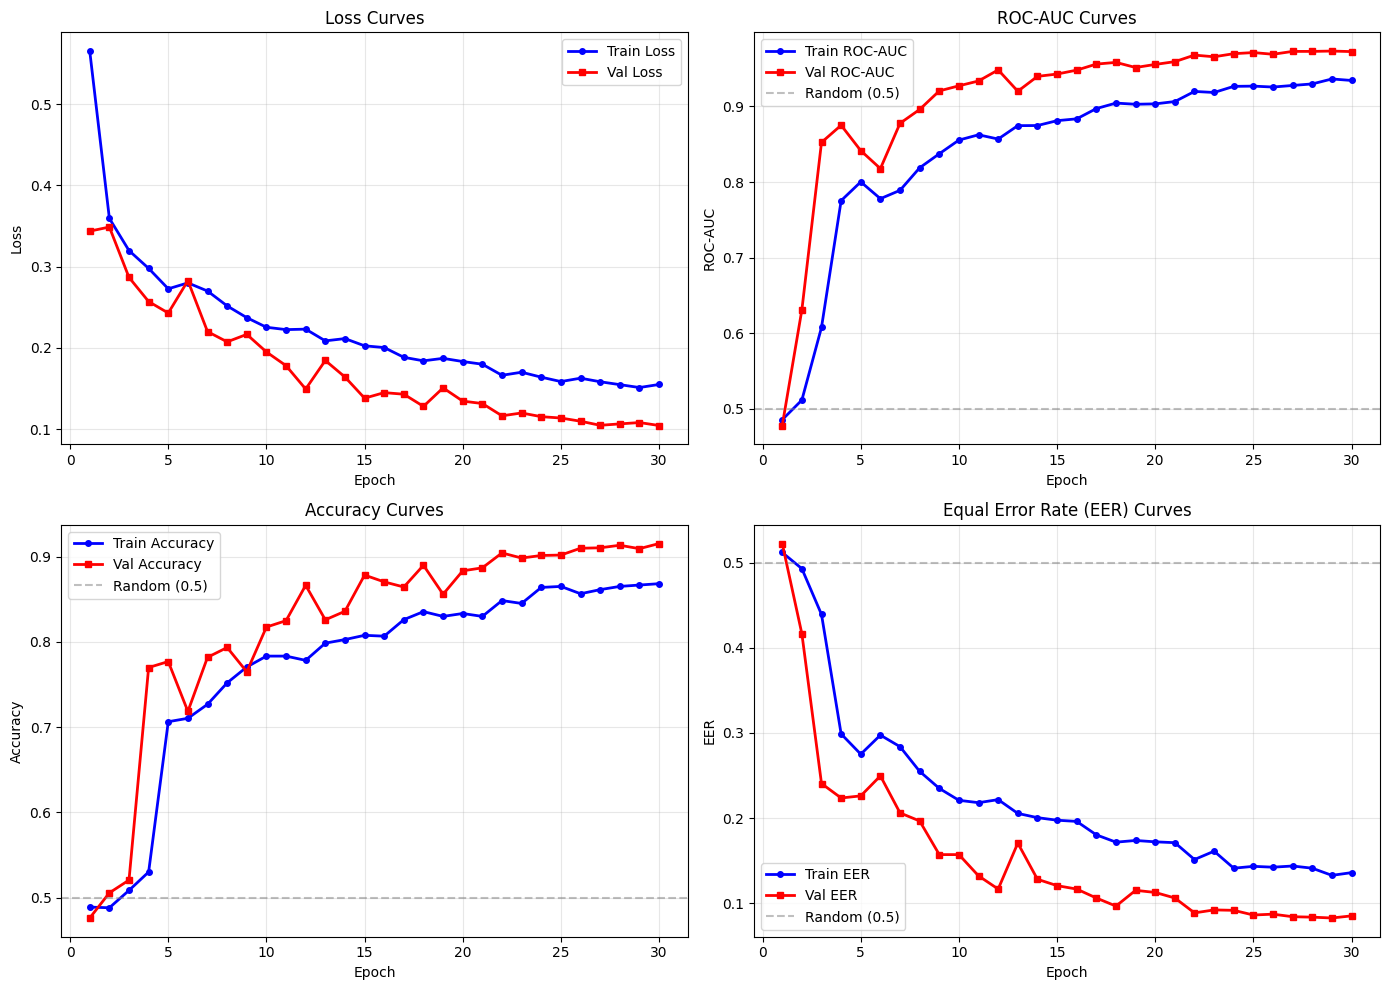

  Best Val ROC-AUC: 0.9731 (Epoch 29)
  Best Val Accuracy: 0.9155 (Epoch 30)
  Best Val EER: 0.0825 (Epoch 29)
  Val ROC-AUC: 0.9724
  Val Accuracy: 0.9155
  Val EER: 0.0850
  Train Loss: 0.1551
  Val Loss: 0.1046
  Best Val ROC-AUC: 0.9731
  Best Val Accuracy: 0.9155
  Best Val EER: 0.0825


In [ ]:
# Data from history_cnn_crossvit_c_b_240
epochs = range(1, len(history_cnn_crossvit_c_b_240['train_loss']) + 1)

train_loss = history_cnn_crossvit_c_b_240['train_loss']
val_loss = history_cnn_crossvit_c_b_240['val_loss']
train_roc_auc = history_cnn_crossvit_c_b_240['train_roc_auc']
val_roc_auc = history_cnn_crossvit_c_b_240['val_roc_auc']
train_accuracy = history_cnn_crossvit_c_b_240['train_accuracy']
val_accuracy = history_cnn_crossvit_c_b_240['val_accuracy']
train_eer = history_cnn_crossvit_c_b_240['train_eer']
val_eer = history_cnn_crossvit_c_b_240['val_eer']
lr = history_cnn_crossvit_c_b_240['lr']

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss Curves
axes[0, 0].plot(epochs, train_loss, 'b-o', label='Train Loss', linewidth=2, markersize=4)
axes[0, 0].plot(epochs, val_loss, 'r-s', label='Val Loss', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. ROC-AUC Curves
axes[0, 1].plot(epochs, train_roc_auc, 'b-o', label='Train ROC-AUC', linewidth=2, markersize=4)
axes[0, 1].plot(epochs, val_roc_auc, 'r-s', label='Val ROC-AUC', linewidth=2, markersize=4)
axes[0, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('ROC-AUC')
axes[0, 1].set_title('ROC-AUC Curves')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Accuracy Curves
axes[1, 0].plot(epochs, train_accuracy, 'b-o', label='Train Accuracy', linewidth=2, markersize=4)
axes[1, 0].plot(epochs, val_accuracy, 'r-s', label='Val Accuracy', linewidth=2, markersize=4)
axes[1, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Accuracy Curves')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. EER Curves
axes[1, 1].plot(epochs, train_eer, 'b-o', label='Train EER', linewidth=2, markersize=4)
axes[1, 1].plot(epochs, val_eer, 'r-s', label='Val EER', linewidth=2, markersize=4)
axes[1, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('EER')
axes[1, 1].set_title('Equal Error Rate (EER) Curves')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_metrics_cnn_crossvit.png', dpi=150, bbox_inches='tight')
plt.show()


best_roc_auc_idx = np.argmax(val_roc_auc)
best_acc_idx = np.argmax(val_accuracy)
best_eer_idx = np.argmin(val_eer)

print(f"  Best Val ROC-AUC: {max(val_roc_auc):.4f} (Epoch {best_roc_auc_idx + 1})")
print(f"  Best Val Accuracy: {max(val_accuracy):.4f} (Epoch {best_acc_idx + 1})")
print(f"  Best Val EER: {min(val_eer):.4f} (Epoch {best_eer_idx + 1})")

print(f"  Val ROC-AUC: {val_roc_auc[-1]:.4f}")
print(f"  Val Accuracy: {val_accuracy[-1]:.4f}")
print(f"  Val EER: {val_eer[-1]:.4f}")
print(f"  Train Loss: {train_loss[-1]:.4f}")
print(f"  Val Loss: {val_loss[-1]:.4f}")

print(f"  Best Val ROC-AUC: {max(val_roc_auc):.4f}")
print(f"  Best Val Accuracy: {max(val_accuracy):.4f}")
print(f"  Best Val EER: {min(val_eer):.4f}")


In [ ]:
checkpoint = torch.load('best_cnn_crossvit_c_b_full_240.pth', map_location='cpu', weights_only=False)

In [ ]:
model = CNNCrossViTWithHead(    embedding_size=256,
    pretrained=False,
    freeze_backbone=None
)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

CNN-CrossViT with Classification Head initialized
Total parameters: 107,597,249
Trainable parameters: 107,597,249 (100.0%)


CNNCrossViTWithHead(
  (cnn_conv1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (cnn_layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=

In [ ]:
model=model.to(device)

In [ ]:
test_results = evaluate_cnn_crossvit_with_head(
        model=model,
        dataloader=test_loader,
        device=device
    )

Evaluating: 100%|██████████| 125/125 [00:40<00:00,  3.09it/s]

  ROC-AUC: 0.9818
  EER: 0.0650
  Accuracy (threshold=0.5): 0.9270
  Mean distance (same author): 0.1790
  Mean distance (different authors): 1.0445
  Distance gap: 0.8654
  Samples: 1000 (pos=536, neg=464)


In [ ]:
result_icdar_chinese = evaluate_cnn_crossvit_with_head(
        model=model,
        dataloader=test_icdar_chinese_loader,
        device=device
    )

print('Results CNNcrossViT C+B')

Evaluating: 100%|██████████| 625/625 [05:08<00:00,  2.02it/s]

  ROC-AUC: 0.7055
  EER: 0.3288
  Accuracy (threshold=0.5): 0.5154
  Mean distance (same author): 0.1692
  Mean distance (different authors): 0.2582
  Distance gap: 0.0890
  Samples: 5000 (pos=2473, neg=2527)
Results CNNcrossViT C+B


In [ ]:
result_icdar_dutch =evaluate_cnn_crossvit_with_head(
        model=model,
        dataloader=test_icdar_dutch_loader,
        device=device
    )
print('Results CNNcrossViT C+B')

Evaluating: 100%|██████████| 625/625 [03:13<00:00,  3.23it/s]

  ROC-AUC: 0.8828
  EER: 0.1826
  Accuracy (threshold=0.5): 0.7340
  Mean distance (same author): 0.1651
  Mean distance (different authors): 0.6675
  Distance gap: 0.5024
  Samples: 5000 (pos=2418, neg=2582)
Results CNNcrossViT C+B


In [ ]:
result_cvl =evaluate_cnn_crossvit_with_head(
        model=model,
        dataloader=test_cvl_loader,
        device=device
    )
print('Results CNNcrossViT C+B')

Evaluating: 100%|██████████| 625/625 [03:17<00:00,  3.16it/s]

  ROC-AUC: 0.7434
  EER: 0.3188
  Accuracy (threshold=0.5): 0.6318
  Mean distance (same author): 0.2255
  Mean distance (different authors): 0.4663
  Distance gap: 0.2407
  Samples: 5000 (pos=2546, neg=2454)
Results CNNcrossViT C+B


In [42]:
def visualize_all_feature_maps(model, image, device, layer_names=None, num_channels=8):
    """
    Visualize feature maps from ANY layers (frozen or trainable).
    Also displays the original input image for reference.
    """
    model.eval()
    original_image = image.cpu().clone()  # Save original for display
    image = image.to(device)

    features = {}

    def get_hook(name):
        def hook(module, input, output):
            features[name] = output.detach()
        return hook

    # List of layers to visualize (any layers can be added)
    if layer_names is None:
        layer_names = [
            'cnn_conv1',        
            'cnn_layer1',         
            'cnn_layer2',         
            'cnn_layer3',          
            'fpn_lateral.0',       
            'fpn_output.0',        
            'crossvit.patch_embed.0.proj',
            'crossvit.blocks.0.fusion.0.attn.proj', 
        ]

    hooks = []
    for name in layer_names:
        # Parse layer name (supports nested attributes and indices)
        parts = name.split('.')
        layer = model
        for part in parts:
            if part.isdigit():
                layer = layer[int(part)]
            elif hasattr(layer, part):
                layer = getattr(layer, part)
            else:
                print(f"Warning: Layer '{name}' not found")
                break
        else:
            hook = layer.register_forward_hook(get_hook(name))
            hooks.append(hook)

    with torch.no_grad():
        _ = model.forward_one(image)

    # Filter to only include layers that were successfully found
    valid_layers = [name for name in layer_names if name in features]
    n_layers = len(valid_layers)

    # Create figure: +1 row for the original image
    fig, axes = plt.subplots(n_layers + 1, num_channels, figsize=(num_channels * 2, (n_layers + 1) * 2))

    # Display original image in the first row
    orig_display = original_image.squeeze().cpu().numpy()
    # Normalize for display
    orig_display = (orig_display - orig_display.min()) / (orig_display.max() - orig_display.min())

    for j in range(num_channels):
        ax = axes[0, j]
        if j == 0:
            ax.imshow(orig_display, cmap='gray')
            ax.set_ylabel('Original\nImage', fontsize=8)
        else:
            ax.axis('off')
        ax.set_title(f'ch{j}' if j == 0 else '', fontsize=6)
        ax.axis('off')

    row = 1
    for name in valid_layers:
        feat = features[name][0]  # [C, H, W]
        num_feat_channels = min(num_channels, feat.shape[0])

        for j in range(num_feat_channels):
            ax = axes[row, j]
            channel = feat[j].cpu()

            # Normalize for visualization
            if channel.std() > 0:
                vmin = channel.quantile(0.05).item()
                vmax = channel.quantile(0.95).item()
                im = ax.imshow(channel, cmap='viridis', vmin=vmin, vmax=vmax)
            else:
                im = ax.imshow(channel, cmap='viridis')

            ax.axis('off')
            if j == 0:
                ax.set_ylabel(name, fontsize=8)

        # Fill empty subplots
        for j in range(num_feat_channels, num_channels):
            axes[row, j].axis('off')

        row += 1

    plt.suptitle('Feature Maps (Original Image + Layer Activations)', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Remove hooks
    for hook in hooks:
        hook.remove()

    return features

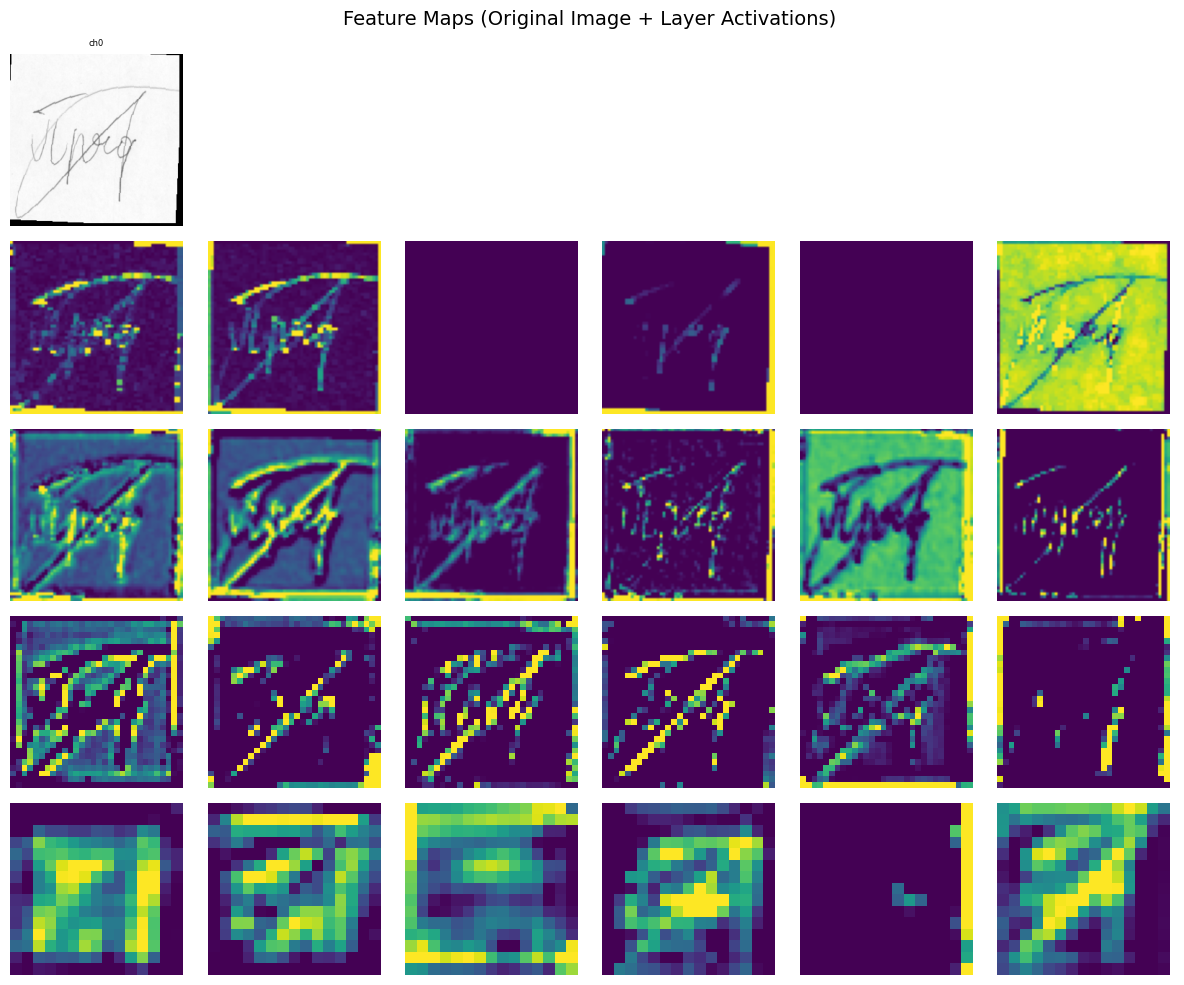

In [ ]:
img = train_dataset[2][0]
img = img.unsqueeze(0).to(device)
features = visualize_all_feature_maps(
        model,
        img,
        device,
        layer_names= [
            'cnn_conv1',
            'cnn_layer1',
            'cnn_layer2',
            'cnn_layer3',
        ],
        num_channels=6
    )


In [43]:
def visualize_saliency_maps(model, image, device, branch='both'):
    """
    Visualize which pixels are most important using gradients.

    Args:
        branch: 'cnn', 'crossvit', or 'both'
    """
    model.eval()
    image = image.to(device)
    image.requires_grad_(True)  # Enable gradients for the input image

    def get_saliency(branch_name):
        # Clear previous gradients
        if image.grad is not None:
            image.grad.zero_()

        # Forward pass
        if branch_name == 'cnn':
            c1 = model.cnn_conv1(image)
            c2 = model.cnn_layer1(c1)
            c3 = model.cnn_layer2(c2)
            c4 = model.cnn_layer3(c3)
            c5 = model.cnn_layer4(c4)
            cnn_features = model._fpn_forward(c2, c3, c4, c5)
            output = cnn_features.sum()
        elif branch_name == 'crossvit':
            crossvit_features = model.crossvit(image)
            output = crossvit_features.sum()
        else:  # both
            emb = model.forward_one(image)
            output = emb.sum()

        # Backward pass
        output.backward()

        saliency = image.grad.abs().detach().cpu().numpy()
        saliency = saliency[0, 0]  # [1, 1, H, W] → [H, W]

        return saliency

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original image (detach for safety)
    axes[0].imshow(image[0, 0].detach().cpu(), cmap='gray')
    axes[0].set_title('Input Image')
    axes[0].axis('off')

    # Saliency map
    saliency = get_saliency(branch)
    im = axes[1].imshow(saliency, cmap='hot')
    axes[1].set_title(f'Saliency Map ({branch})')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1])

    # Overlay (blended image and saliency map)
    axes[2].imshow(image[0, 0].detach().cpu(), cmap='gray', alpha=0.5)
    axes[2].imshow(saliency, cmap='hot', alpha=0.5)
    axes[2].set_title('Overlay (Saliency + Image)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    # Clear gradients after use to avoid memory issues
    if image.grad is not None:
        image.grad = None

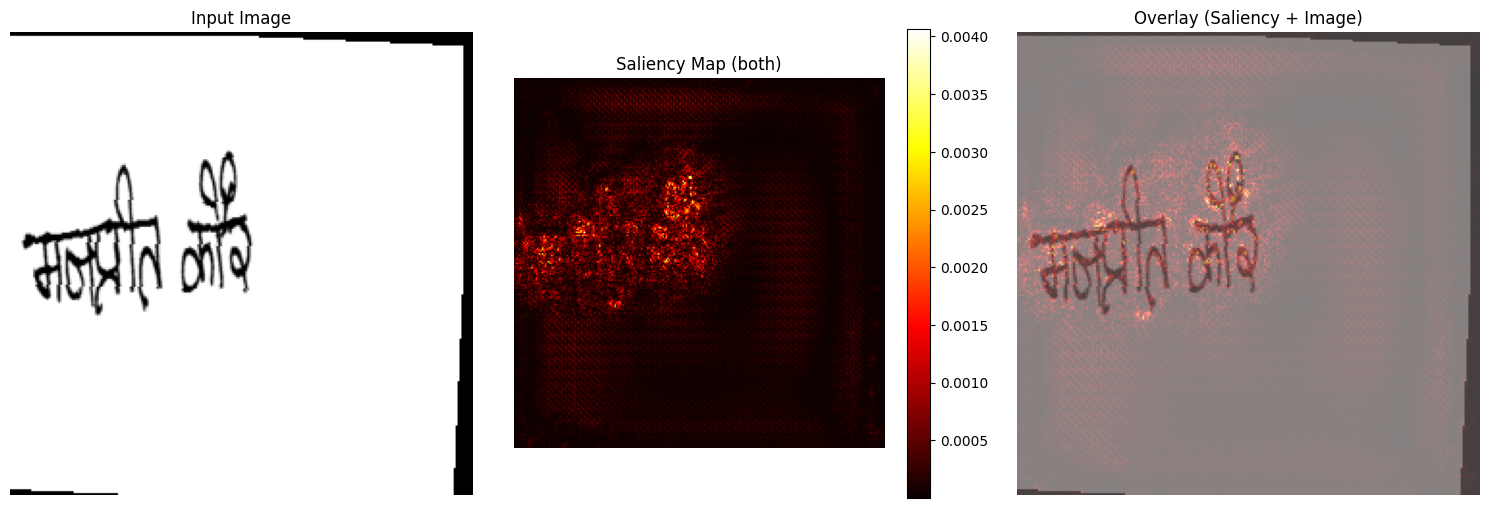

In [ ]:
visualize_saliency_maps(model, train_dataset[0][0].unsqueeze(0).to(device), device)

In [44]:
def visualize_author_embeddings(model, cedar_root, author_ids, transform, device):
    """
    Visualize embeddings for selected authors from CEDAR dataset.
    """
    model.eval()

    embeddings = []
    labels = []
    colors_list = []
    marker_styles = []

    # Colors for different authors
    author_colors = ['blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta']
    # Marker styles: o for original, x for forgery
    marker_map = {'original': 'o', 'forgery': 'x'}

    for author_idx, author_id in enumerate(author_ids):
        author_color = author_colors[author_idx % len(author_colors)]

        # Load original signatures
        original_path = os.path.join(cedar_root, 'original', author_id)
        if os.path.exists(original_path):
            for img_file in os.listdir(original_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(original_path, img_file)
                    img = Image.open(img_path).convert('L')
                    img_tensor = transform(img).unsqueeze(0).to(device)

                    with torch.no_grad():
                        emb = model.forward_one(img_tensor).cpu().numpy()[0]

                    embeddings.append(emb)
                    labels.append(f'Author {author_id}')
                    colors_list.append(author_color)
                    marker_styles.append('o')

        # Load forgery signatures
        forgery_path = os.path.join(cedar_root, 'forgery', author_id)
        if os.path.exists(forgery_path):
            for img_file in os.listdir(forgery_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(forgery_path, img_file)
                    img = Image.open(img_path).convert('L')
                    img_tensor = transform(img).unsqueeze(0).to(device)

                    with torch.no_grad():
                        emb = model.forward_one(img_tensor).cpu().numpy()[0]

                    embeddings.append(emb)
                    labels.append(f'Author {author_id}')
                    colors_list.append(author_color)
                    marker_styles.append('x')

    embeddings = np.array(embeddings)

    # t-SNE
    perplexity = min(30, len(embeddings) - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    embeddings_2d = tsne.fit_transform(embeddings)

    # Plot
    plt.figure(figsize=(12, 10))

    # Plot each point individually with correct color and marker
    for i, (x, y) in enumerate(embeddings_2d):
        plt.scatter(x, y, c=colors_list[i], marker=marker_styles[i],
                   s=100, alpha=0.7, edgecolors='black', linewidth=0.5)

    # Create custom legend
    legend_elements = []
    for author_idx, author_id in enumerate(author_ids):
        author_color = author_colors[author_idx % len(author_colors)]
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                          markerfacecolor=author_color,
                                          markersize=10, label=f'Author {author_id} (original)'))
        legend_elements.append(plt.Line2D([0], [0], marker='x', color='w',
                                          markerfacecolor=author_color,
                                          markersize=10, label=f'Author {author_id} (forgery)'))

    plt.legend(handles=legend_elements, fontsize=9, loc='best')
    plt.title(f't-SNE visualization of embeddings for {len(author_ids)} authors\n(o = original, x = forgery)', fontsize=14)
    plt.xlabel('t-SNE component 1')
    plt.ylabel('t-SNE component 2')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


    for author_id in author_ids:
        # Get indices for this author
        author_indices = [i for i, label in enumerate(labels) if label == f'Author {author_id}']
        orig_indices = [i for i in author_indices if marker_styles[i] == 'o']
        forg_indices = [i for i in author_indices if marker_styles[i] == 'x']

        print(f"\nAuthor {author_id}:")
        print(f"  Original signatures: {len(orig_indices)}")
        print(f"  Forgery signatures: {len(forg_indices)}")

        if len(orig_indices) > 0 and len(forg_indices) > 0:
            orig_center = np.mean(embeddings[orig_indices], axis=0)
            forg_center = np.mean(embeddings[forg_indices], axis=0)
            dist = np.linalg.norm(orig_center - forg_center)
            print(f"  Distance between original and forgery centers: {dist:.4f}")

/tmp/ipykernel_868/800764944.py:77: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x, y, c=colors_list[i], marker=marker_styles[i],


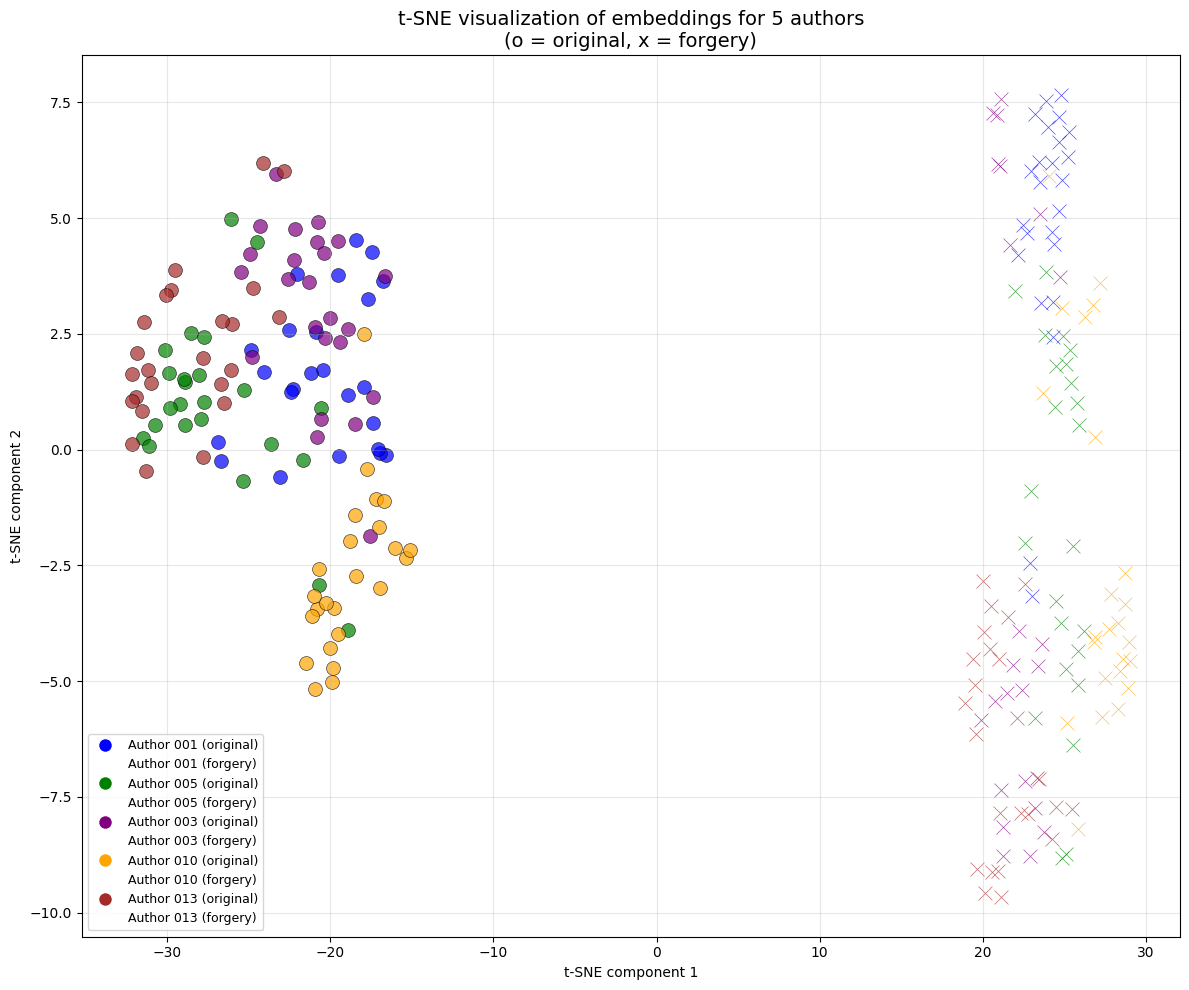


Author 001:
  Original signatures: 24
  Forgery signatures: 24
  Distance between original and forgery centers: 1.7544

Author 005:
  Original signatures: 24
  Forgery signatures: 24
  Distance between original and forgery centers: 1.6430

Author 003:
  Original signatures: 24
  Forgery signatures: 24
  Distance between original and forgery centers: 1.5870

Author 010:
  Original signatures: 24
  Forgery signatures: 24
  Distance between original and forgery centers: 1.6050

Author 013:
  Original signatures: 24
  Forgery signatures: 24
  Distance between original and forgery centers: 1.5336


In [ ]:
author_ids = ['001', '005', '003', '010', '013'] 

cedar_root = '/kaggle/working/all_data_3/cedar' 

visualize_author_embeddings(model, cedar_root, author_ids, test_transform, device)

In [45]:
def visualize_iam_embeddings(model, iam_root, author_ids, transform, device):
    """
    Visualize embeddings for selected authors from IAM dataset.

    Args:
        model: trained model
        iam_root: path to IAM folder (contains subfolders with author IDs)
        author_ids: list of author IDs to visualize (e.g., ['001', '002', '003'])
        transform: image transformations
        device: cuda or cpu
    """
    model.eval()

    embeddings = []
    labels = []
    colors_list = []

    # Colors for different authors
    author_colors = ['blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta']

    valid_author_ids = []

    for author_idx, author_id in enumerate(author_ids):
        author_color = author_colors[author_idx % len(author_colors)]
        author_path = os.path.join(iam_root, author_id)


        valid_author_ids.append(author_id)

        # Load all images for this author
        image_files = [f for f in os.listdir(author_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.bmp'))]


        for img_file in image_files:
            img_path = os.path.join(author_path, img_file)
            try:
                img = Image.open(img_path).convert('L')
                img_tensor = transform(img).unsqueeze(0).to(device)

                with torch.no_grad():
                    emb = model.forward_one(img_tensor).cpu().numpy()[0]

                embeddings.append(emb)
                labels.append(f'Author {author_id}')
                colors_list.append(author_color)
    embeddings = np.array(embeddings)
    n_samples = len(embeddings)

    # t-SNE with proper perplexity
    if n_samples <= 1:
        print("Need at least 2 samples for t-SNE")
        return
    elif n_samples < 5:
        perplexity = max(1, n_samples - 1)
    else:
        perplexity = min(30, n_samples - 1)


    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    embeddings_2d = tsne.fit_transform(embeddings)

    # Plot
    plt.figure(figsize=(12, 10))

    # Plot each point with different colors per author
    for i, (x, y) in enumerate(embeddings_2d):
        plt.scatter(x, y, c=colors_list[i], marker='o',
                   s=80, alpha=0.7, edgecolors='black', linewidth=0.5)

    # Create custom legend
    legend_elements = []
    for author_idx, author_id in enumerate(valid_author_ids):
        author_color = author_colors[author_idx % len(author_colors)]
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                          markerfacecolor=author_color,
                                          markersize=10, label=f'Author {author_id}'))

    plt.legend(handles=legend_elements, fontsize=10, loc='best')
    plt.title(f't-SNE visualization of IAM embeddings for {len(valid_author_ids)} authors\n({n_samples} total signatures)', fontsize=14)
    plt.xlabel('t-SNE component 1')
    plt.ylabel('t-SNE component 2')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    for author_id in valid_author_ids:
        author_indices = [i for i, label in enumerate(labels) if label == f'Author {author_id}']
        if len(author_indices) > 1:
            embeddings_author = embeddings[author_indices]
            center = np.mean(embeddings_author, axis=0)

            # Calculate intra-class distances
            intra_distances = []
            for i in range(len(embeddings_author)):
                for j in range(i+1, len(embeddings_author)):
                    dist = np.linalg.norm(embeddings_author[i] - embeddings_author[j])
                    intra_distances.append(dist)

            print(f"\nAuthor {author_id}:")
            print(f"  Number of images: {len(author_indices)}")
            print(f"  Mean intra-class distance: {np.mean(intra_distances):.4f}")
            print(f"  Std intra-class distance: {np.std(intra_distances):.4f}")
            print(f"  Min distance: {np.min(intra_distances):.4f}")
            print(f"  Max distance: {np.max(intra_distances):.4f}")
        elif len(author_indices) == 1:
            print(f"\nAuthor {author_id}:")
            print(f"  Number of images: 1")
            print(f"  Cannot compute intra-class distance (need at least 2 images)")

    unique_authors = [f'Author {aid}' for aid in valid_author_ids]
    for i, auth1 in enumerate(unique_authors):
        for j, auth2 in enumerate(unique_authors):
            if i < j:
                idx1 = [k for k, label in enumerate(labels) if label == auth1]
                idx2 = [k for k, label in enumerate(labels) if label == auth2]

                if idx1 and idx2 and len(idx1) > 0 and len(idx2) > 0:
                    center1 = np.mean(embeddings[idx1], axis=0)
                    center2 = np.mean(embeddings[idx2], axis=0)
                    dist = np.linalg.norm(center1 - center2)
                    print(f"  {auth1} vs {auth2}: {dist:.4f}")


    if len(valid_author_ids) >= 2:
        # Calculate average inter-class distance
        inter_distances = []
        for i, auth1 in enumerate(unique_authors):
            for j, auth2 in enumerate(unique_authors):
                if i < j:
                    idx1 = [k for k, label in enumerate(labels) if label == auth1]
                    idx2 = [k for k, label in enumerate(labels) if label == auth2]
                    if idx1 and idx2:
                        center1 = np.mean(embeddings[idx1], axis=0)
                        center2 = np.mean(embeddings[idx2], axis=0)
                        inter_distances.append(np.linalg.norm(center1 - center2))

        # Calculate average intra-class distance
        intra_distances_all = []
        for author_id in valid_author_ids:
            author_indices = [i for i, label in enumerate(labels) if label == f'Author {author_id}']
            if len(author_indices) > 1:
                embeddings_author = embeddings[author_indices]
                for i in range(len(embeddings_author)):
                    for j in range(i+1, len(embeddings_author)):
                        intra_distances_all.append(np.linalg.norm(embeddings_author[i] - embeddings_author[j]))

        if intra_distances_all and inter_distances:
            avg_intra = np.mean(intra_distances_all)
            avg_inter = np.mean(inter_distances)
            separation_ratio = avg_inter / avg_intra if avg_intra > 0 else float('inf')

            print(f"Average intra-class distance: {avg_intra:.4f}")
            print(f"Average inter-class distance: {avg_inter:.4f}")
            print(f"Separation ratio (inter/intra): {separation_ratio:.4f}")
            if separation_ratio > 1:
                print("Authors are well separated (inter > intra)")
            else:
                print("Authors are not well separated (inter < intra)")

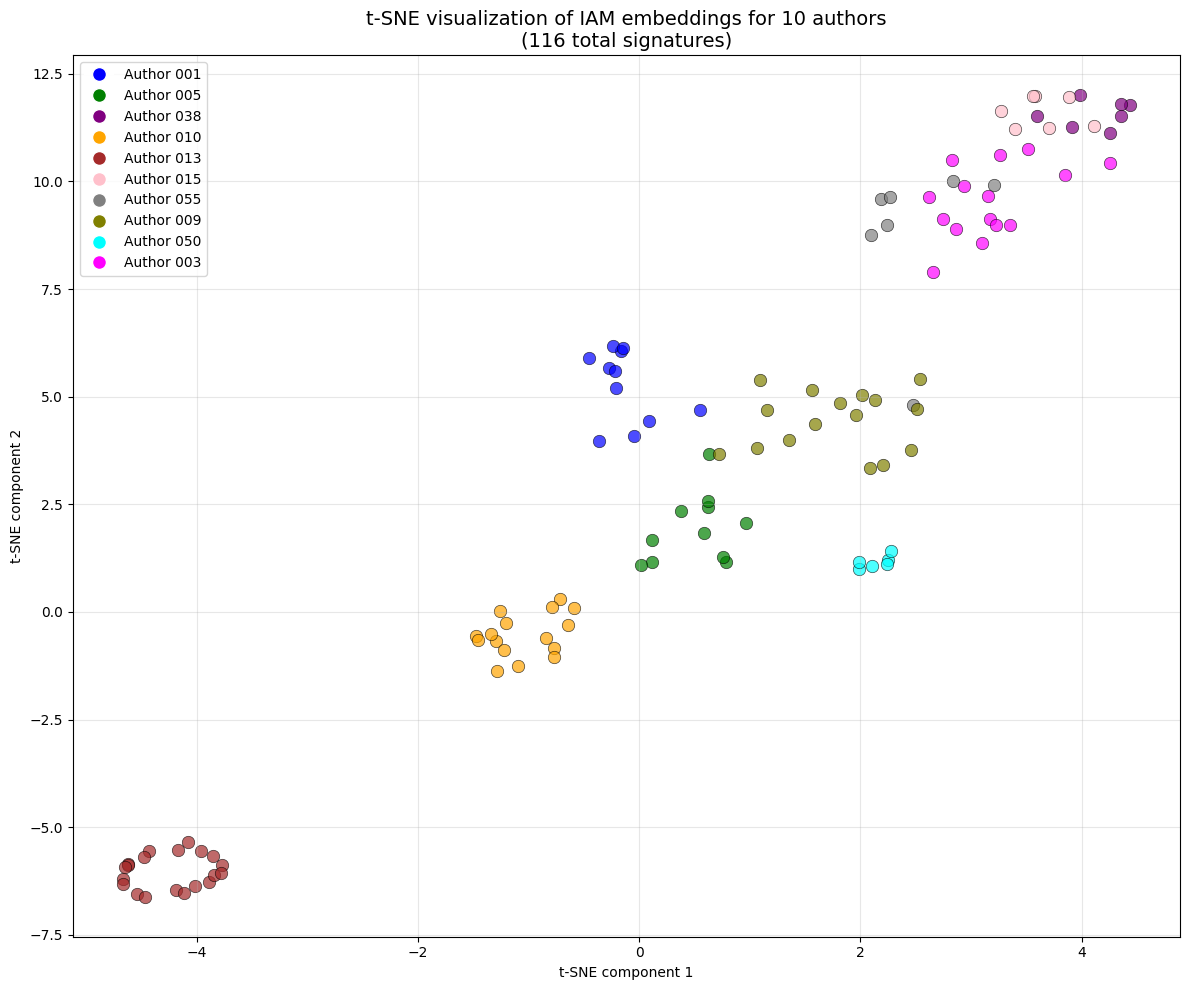


Author 001:
  Number of images: 11
  Mean intra-class distance: 0.2335
  Std intra-class distance: 0.1139
  Min distance: 0.0259
  Max distance: 0.4625

Author 005:
  Number of images: 11
  Mean intra-class distance: 0.2517
  Std intra-class distance: 0.1031
  Min distance: 0.0372
  Max distance: 0.5061

Author 038:
  Number of images: 7
  Mean intra-class distance: 0.0844
  Std intra-class distance: 0.0290
  Min distance: 0.0273
  Max distance: 0.1330

Author 010:
  Number of images: 16
  Mean intra-class distance: 0.2175
  Std intra-class distance: 0.1033
  Min distance: 0.0408
  Max distance: 0.5537

Author 013:
  Number of images: 20
  Mean intra-class distance: 0.1877
  Std intra-class distance: 0.1014
  Min distance: 0.0238
  Max distance: 0.5323

Author 015:
  Number of images: 7
  Mean intra-class distance: 0.0847
  Std intra-class distance: 0.0320
  Min distance: 0.0137
  Max distance: 0.1287

Author 055:
  Number of images: 7
  Mean intra-class distance: 0.2190
  Std intra-c

In [ ]:
author_ids = ['001', '005', '038', '010', '013',  '015',  '055',  '009', '050', '003'] 

iam_root = '/kaggle/working/all_data_3/iam'  

visualize_iam_embeddings(model, iam_root, author_ids, test_transform, device)

In [46]:
def visualize_author_embeddings_hindi(model, hindi_root, author_ids, transform, device):
    """
    Visualize embeddings for selected authors from Hindi dataset.
    Dataset structure: hindi_root/author_id/genuine/ and hindi_root/author_id/forge/
    """
    model.eval()

    embeddings = []
    labels = []
    colors_list = []
    marker_styles = []

    # Colors for different authors
    author_colors = ['blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta']
    # Marker styles: o for genuine, x for forge
    marker_map = {'genuine': 'o', 'forge': 'x'}

    for author_idx, author_id in enumerate(author_ids):
        author_color = author_colors[author_idx % len(author_colors)]
        author_path = os.path.join(hindi_root, author_id)

        if not os.path.exists(author_path):
            print(f"Warning: Author path {author_path} does not exist")
            continue

        # Load genuine signatures
        genuine_path = os.path.join(author_path, 'genuine')
        if os.path.exists(genuine_path):
            for img_file in os.listdir(genuine_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg', 'tif')):
                    img_path = os.path.join(genuine_path, img_file)
                    img = Image.open(img_path).convert('L')
                    img_tensor = transform(img).unsqueeze(0).to(device)

                    with torch.no_grad():
                        emb = model.forward_one(img_tensor).cpu().numpy()[0]

                    embeddings.append(emb)
                    labels.append(f'Author {author_id}')
                    colors_list.append(author_color)
                    marker_styles.append('o')

        # Load forge signatures
        forge_path = os.path.join(author_path, 'forge')
        if os.path.exists(forge_path):
            for img_file in os.listdir(forge_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg', 'tif')):
                    img_path = os.path.join(forge_path, img_file)
                    img = Image.open(img_path).convert('L')
                    img_tensor = transform(img).unsqueeze(0).to(device)

                    with torch.no_grad():
                        emb = model.forward_one(img_tensor).cpu().numpy()[0]

                    embeddings.append(emb)
                    labels.append(f'Author {author_id}')
                    colors_list.append(author_color)
                    marker_styles.append('x')

    if len(embeddings) < 2:
        print("Not enough embeddings found. Check the paths.")
        return

    embeddings = np.array(embeddings)

    # t-SNE
    perplexity = min(30, len(embeddings) - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    embeddings_2d = tsne.fit_transform(embeddings)

    # Plot
    plt.figure(figsize=(12, 10))

    # Plot each point individually with correct color and marker
    for i, (x, y) in enumerate(embeddings_2d):
        plt.scatter(x, y, c=colors_list[i], marker=marker_styles[i],
                   s=100, alpha=0.7, edgecolors='black', linewidth=0.5)

    # Create custom legend
    legend_elements = []
    for author_idx, author_id in enumerate(author_ids):
        author_color = author_colors[author_idx % len(author_colors)]
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                          markerfacecolor=author_color,
                                          markersize=10, label=f'Author {author_id} (genuine)'))
        legend_elements.append(plt.Line2D([0], [0], marker='x', color='w',
                                          markerfacecolor=author_color,
                                          markersize=10, label=f'Author {author_id} (forge)'))

    plt.legend(handles=legend_elements, fontsize=9, loc='best')
    plt.title(f't-SNE visualization of embeddings for {len(author_ids)} authors\n(o = genuine, x = forge)', fontsize=14)
    plt.xlabel('t-SNE component 1')
    plt.ylabel('t-SNE component 2')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print statistics for each author
    for author_id in author_ids:
        # Get indices for this author
        author_indices = [i for i, label in enumerate(labels) if label == f'Author {author_id}']
        genuine_indices = [i for i in author_indices if marker_styles[i] == 'o']
        forge_indices = [i for i in author_indices if marker_styles[i] == 'x']

        print(f"\nAuthor {author_id}:")
        print(f"  Genuine signatures: {len(genuine_indices)}")
        print(f"  Forge signatures: {len(forge_indices)}")

        if len(genuine_indices) > 0 and len(forge_indices) > 0:
            genuine_center = np.mean(embeddings[genuine_indices], axis=0)
            forge_center = np.mean(embeddings[forge_indices], axis=0)
            dist = np.linalg.norm(genuine_center - forge_center)
            print(f"  Distance between genuine and forge centers: {dist:.4f}")

/tmp/ipykernel_868/3220041324.py:76: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x, y, c=colors_list[i], marker=marker_styles[i],


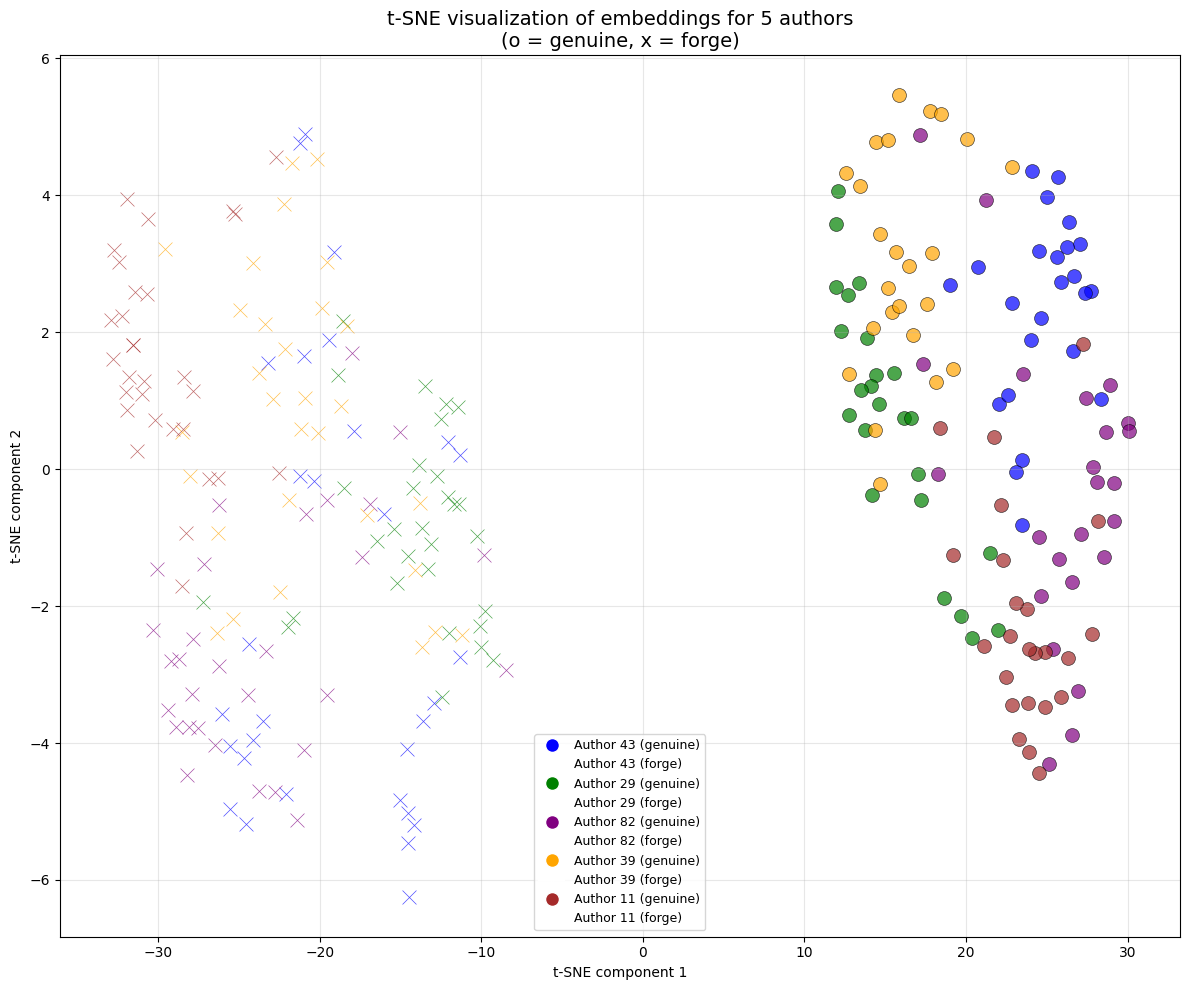


Author 43:
  Genuine signatures: 24
  Forge signatures: 30
  Distance between genuine and forge centers: 1.0679

Author 29:
  Genuine signatures: 24
  Forge signatures: 30
  Distance between genuine and forge centers: 0.8001

Author 82:
  Genuine signatures: 24
  Forge signatures: 30
  Distance between genuine and forge centers: 1.2731

Author 39:
  Genuine signatures: 24
  Forge signatures: 30
  Distance between genuine and forge centers: 0.9846

Author 11:
  Genuine signatures: 24
  Forge signatures: 30
  Distance between genuine and forge centers: 1.5091


In [ ]:
author_ids = ['43', '29', '82', '39', '11']

hindi_root = '/kaggle/working/all_data_3/hindi'

visualize_author_embeddings_hindi(model, hindi_root, author_ids, test_transform, device)

/tmp/ipykernel_868/3220041324.py:76: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x, y, c=colors_list[i], marker=marker_styles[i],


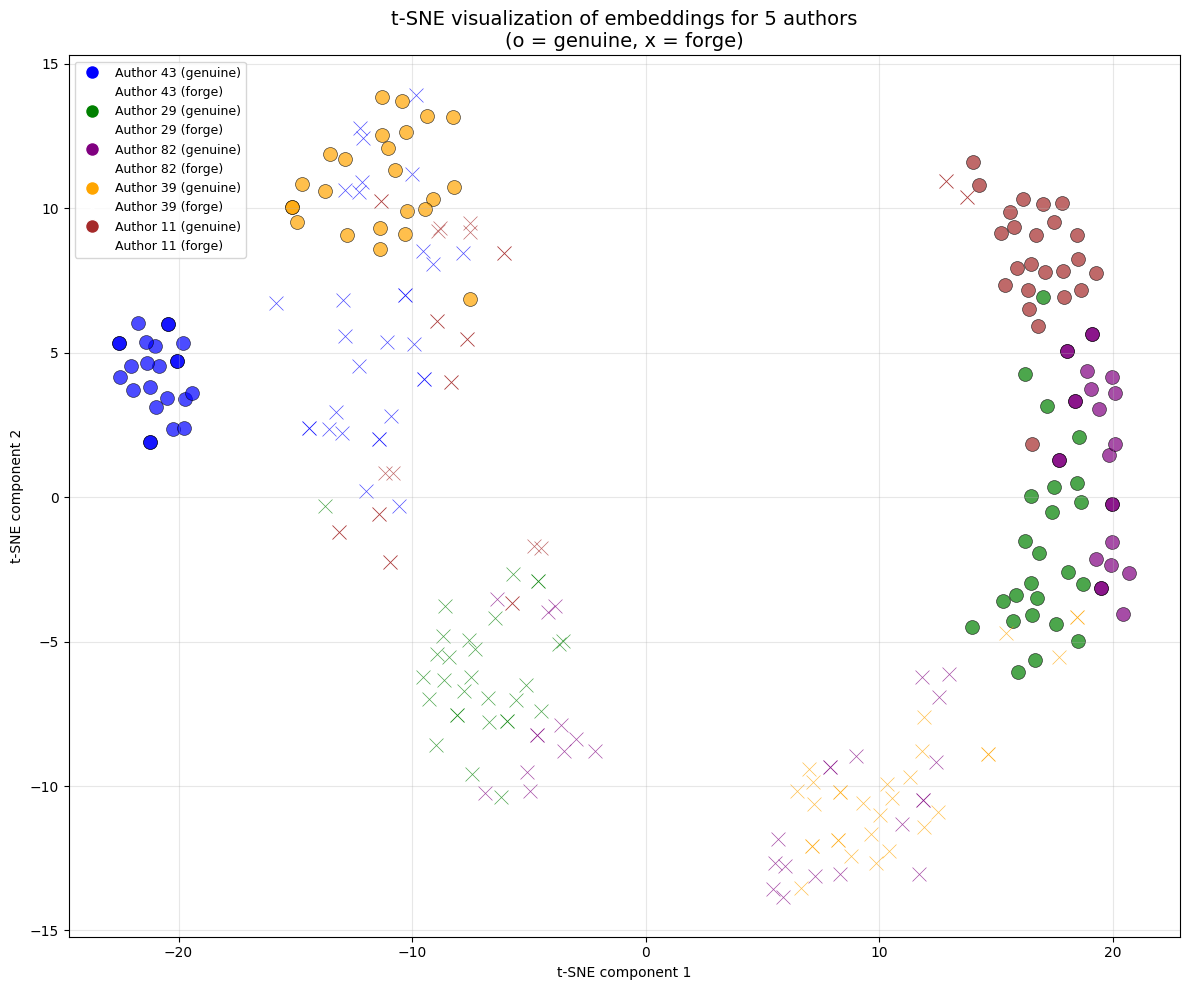


Author 43:
  Genuine signatures: 24
  Forge signatures: 30
  Distance between genuine and forge centers: 0.6059

Author 29:
  Genuine signatures: 24
  Forge signatures: 30
  Distance between genuine and forge centers: 1.3351

Author 82:
  Genuine signatures: 24
  Forge signatures: 30
  Distance between genuine and forge centers: 1.1991

Author 39:
  Genuine signatures: 24
  Forge signatures: 30
  Distance between genuine and forge centers: 1.4758

Author 11:
  Genuine signatures: 24
  Forge signatures: 30
  Distance between genuine and forge centers: 1.0325


In [ ]:
author_ids = ['43', '29', '82', '39', '11']

bengali_root = '/kaggle/working/all_data_3/bengali'

visualize_author_embeddings_hindi(model, bengali_root, author_ids, test_transform, device)

/tmp/ipykernel_868/3220041324.py:76: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x, y, c=colors_list[i], marker=marker_styles[i],


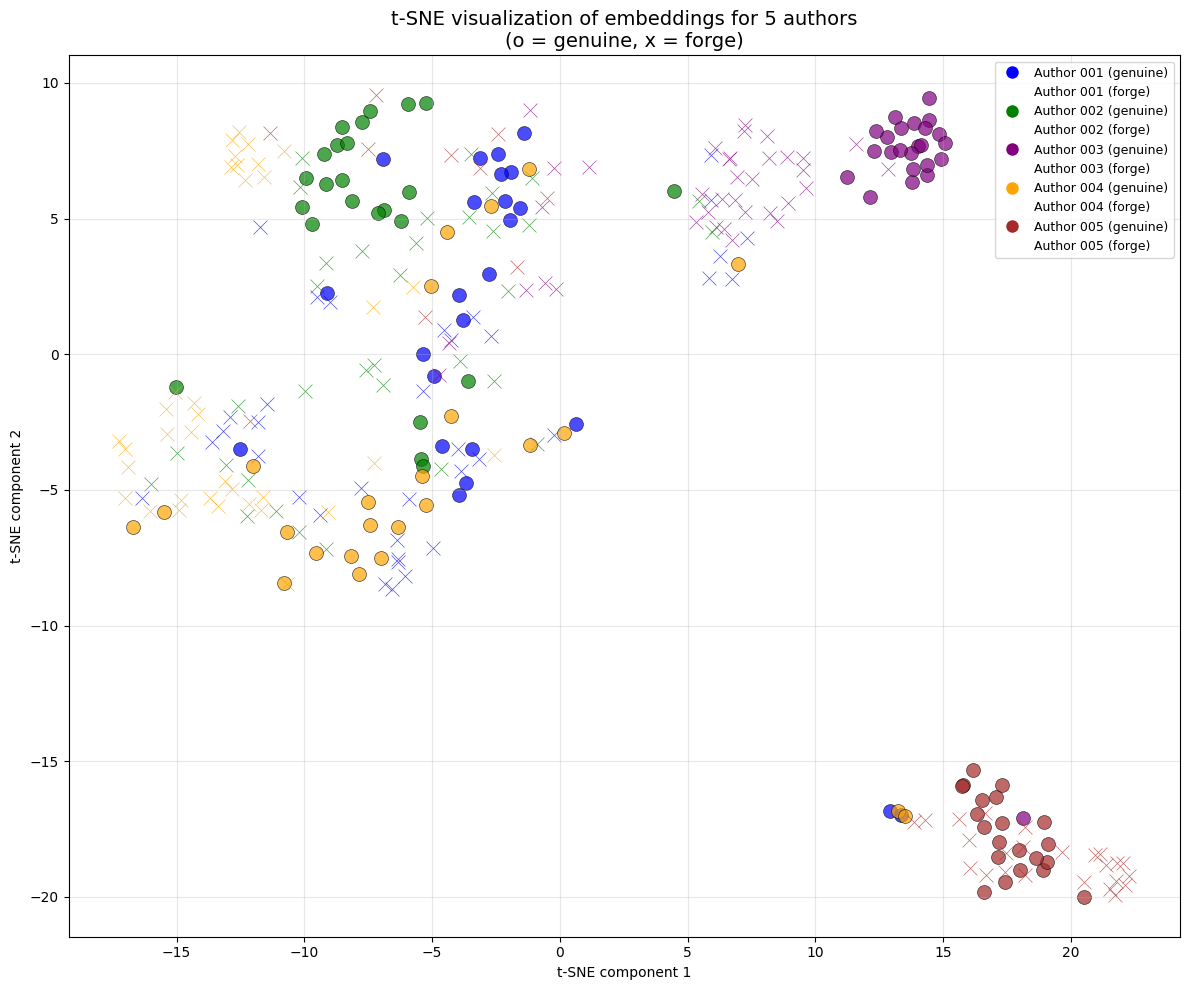


Author 001:
  Genuine signatures: 24
  Forge signatures: 36
  Distance between genuine and forge centers: 0.0829

Author 002:
  Genuine signatures: 24
  Forge signatures: 34
  Distance between genuine and forge centers: 0.0983

Author 003:
  Genuine signatures: 24
  Forge signatures: 36
  Distance between genuine and forge centers: 0.1992

Author 004:
  Genuine signatures: 24
  Forge signatures: 36
  Distance between genuine and forge centers: 0.2214

Author 005:
  Genuine signatures: 21
  Forge signatures: 34
  Distance between genuine and forge centers: 0.1338


In [ ]:
author_ids = ['001', '002', '003', '004', '005']

visualize_author_embeddings_hindi(model, "/kaggle/working/icdar_chinese", author_ids, test_transform, device)

/tmp/ipykernel_868/3220041324.py:76: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x, y, c=colors_list[i], marker=marker_styles[i],


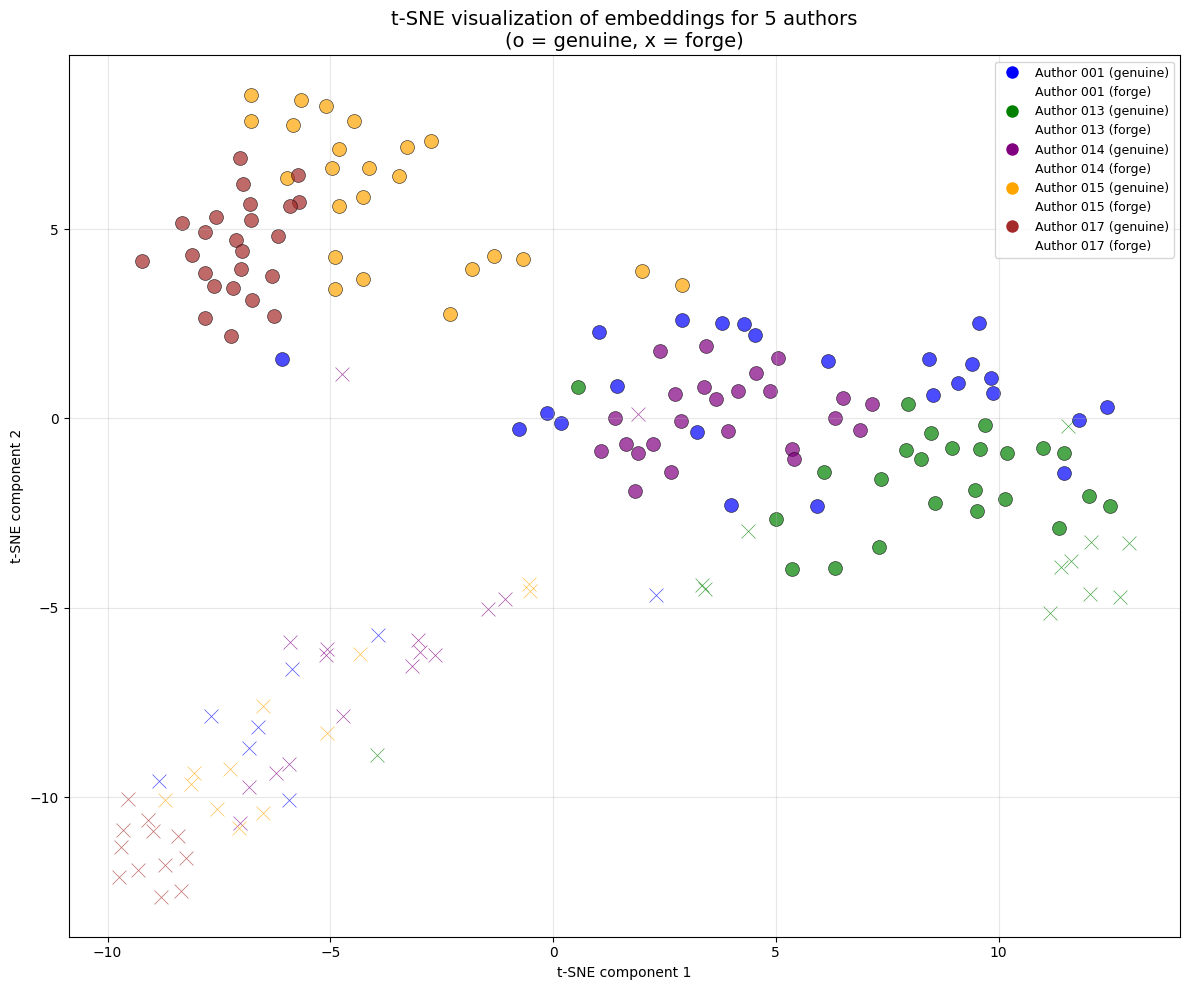


Author 001:
  Genuine signatures: 24
  Forge signatures: 8
  Distance between genuine and forge centers: 0.6659

Author 013:
  Genuine signatures: 24
  Forge signatures: 12
  Distance between genuine and forge centers: 0.2424

Author 014:
  Genuine signatures: 24
  Forge signatures: 16
  Distance between genuine and forge centers: 0.4699

Author 015:
  Genuine signatures: 24
  Forge signatures: 12
  Distance between genuine and forge centers: 0.6852

Author 017:
  Genuine signatures: 24
  Forge signatures: 12
  Distance between genuine and forge centers: 1.0747


In [ ]:
author_ids = ['001', '013', '014', '015', '017']

visualize_author_embeddings_hindi(model, "/kaggle/working/icdar_dutch", author_ids, test_transform, device)

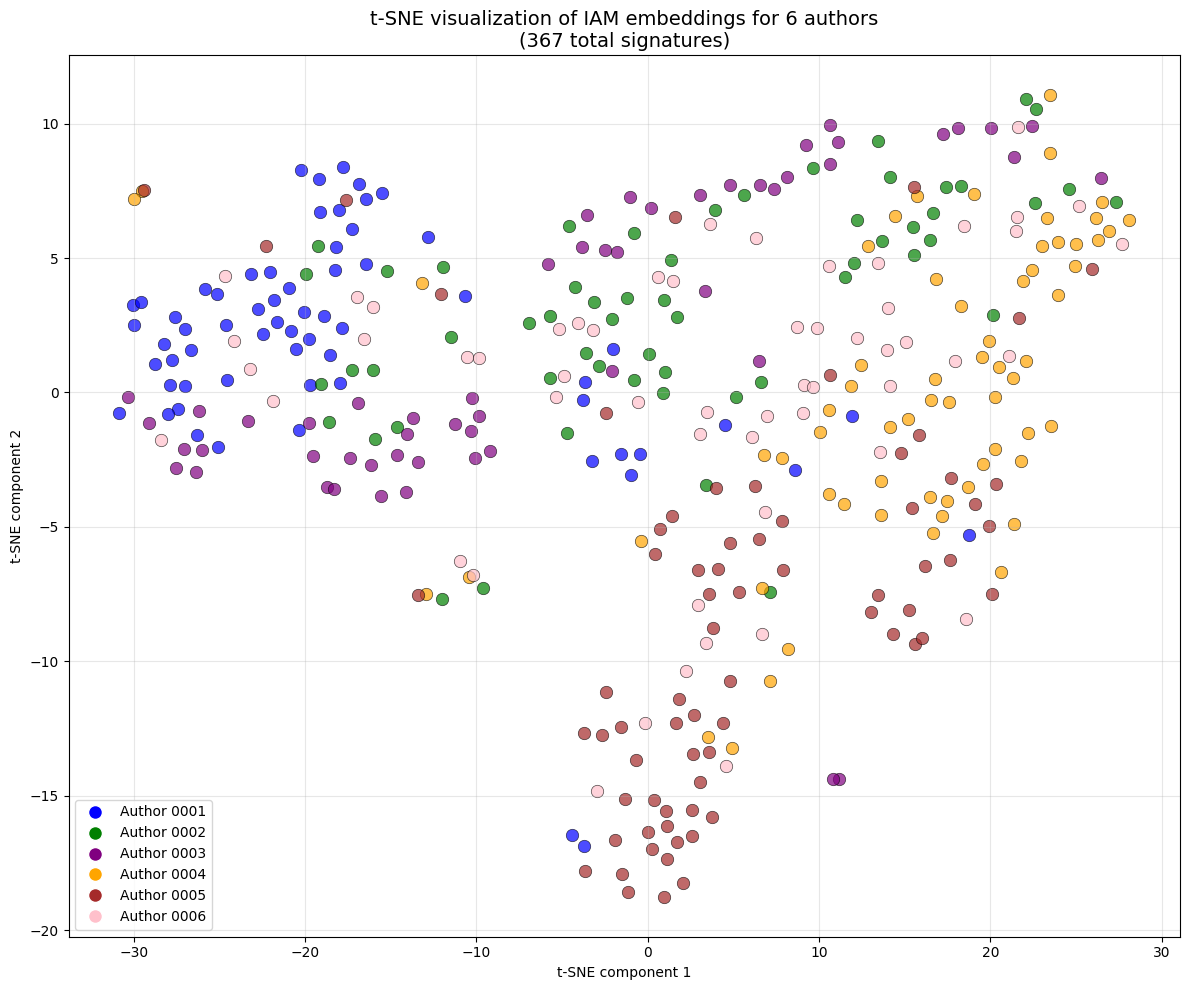


Author 0001:
  Number of images: 64
  Mean intra-class distance: 0.1370
  Std intra-class distance: 0.0863
  Min distance: 0.0095
  Max distance: 0.6036

Author 0002:
  Number of images: 57
  Mean intra-class distance: 0.1740
  Std intra-class distance: 0.1089
  Min distance: 0.0144
  Max distance: 0.5915

Author 0003:
  Number of images: 54
  Mean intra-class distance: 0.1864
  Std intra-class distance: 0.1168
  Min distance: 0.0128
  Max distance: 0.7010

Author 0004:
  Number of images: 65
  Mean intra-class distance: 0.2413
  Std intra-class distance: 0.2942
  Min distance: 0.0146
  Max distance: 1.5894

Author 0005:
  Number of images: 71
  Mean intra-class distance: 0.2259
  Std intra-class distance: 0.2310
  Min distance: 0.0155
  Max distance: 1.5795

Author 0006:
  Number of images: 56
  Mean intra-class distance: 0.1864
  Std intra-class distance: 0.1047
  Min distance: 0.0111
  Max distance: 0.6047
  Author 0001 vs Author 0002: 0.1958
  Author 0001 vs Author 0003: 0.1562
  

In [ ]:
author_ids = ['0001', '0002', '0003', '0004', '0005',  '0006']
visualize_iam_embeddings(model, "/kaggle/working/cvl", author_ids, test_transform, device)